In [1]:
from __future__ import annotations

%load_ext autoreload
%autoreload 2

In [22]:
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
from typing import Sequence
from pydantic import Field
from pydantic import BaseModel

from protein_search_evals.utils import BaseConfig
from protein_search_evals.evaluate import EvaluatorOutput

In [30]:
def plot_histogram(
    data: list[float | int],
    xlabel: str,
    ylabel: str,
    title: str = "",
    bins: int | None = None,
    save_path: str | None = None
) -> None:
    """Plot a histogram with automatically computed number of bins.

    Parameters
    ----------
    data : list[float | int]
        Data to plot in the histogram.
    xlabel : str
        Label for the x-axis.
    ylabel : str
        Label for the y-axis.
    title : str, optional
        Title of the plot, by default "" (no title).
    bins : int | None, optional
        The number of bins to use.
    save_path : str | None, optional
        If provided, saves the figure to the given path, by default None.
    
    Returns
    -------
    None
    """
    # High-quality publication settings
    plt.style.use('seaborn-v0_8-paper')
    plt.rcParams.update({
        'font.family': 'serif',
        'font.size': 14,
        'axes.titlesize': 16,
        'axes.labelsize': 14,
        'xtick.labelsize': 12,
        'ytick.labelsize': 12,
        'figure.dpi': 300,
    })

    # Create figure and axis
    fig, ax = plt.subplots(figsize=(8, 6))

    # Plot the histogram
    ax.hist(data, bins=bins, color='steelblue', edgecolor='black', alpha=0.7)

    # Customize the plot
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    
    if title:
        ax.set_title(title)
    ax.grid(True, linestyle='--', linewidth=0.7, alpha=0.7)

    # Optimize layout
    plt.tight_layout()

    # Save if a path is provided
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    # Show the plot
    plt.show()


def plot_histograms(
    datasets: Sequence[Sequence[float | int]],
    labels: list[str],
    xlabel: str,
    ylabel: str,
    title: str = "",
    bins: int | None = None,
    save_path: str | None = None,
    alpha: float = 0.6,
    colors: list[str] = ["blue", "green"],
) -> None:
    """Plot multiple histograms on the same axes with specified colors.

    Parameters
    ----------
    datasets : Sequence of lists of float | int
        Each dataset will be plotted as a separate histogram.
    labels : list of str
        Labels for each dataset.
    xlabel : str
        Label for the x-axis.
    ylabel : str
        Label for the y-axis.
    title : str, optional
        Title of the plot, by default "" (no title).
    bins : int | None, optional
        Number of bins to use, shared across all datasets if provided.
    save_path : str | None, optional
        If provided, saves the figure to the given path.
    alpha : float, optional
        Transparency level for overlapping histograms.
    colors : list of str, optional
        Colors to use for the histograms, by default ["blue", "green"].
    
    Returns
    -------
    None
    """
    assert len(datasets) == len(labels), "Each dataset must have a corresponding label"
    if len(colors) < len(datasets):
        raise ValueError("Not enough colors specified for the number of datasets")

    # High-quality publication settings
    plt.style.use('seaborn-v0_8-paper')
    plt.rcParams.update({
        'font.family': 'serif',
        'font.size': 14,
        'axes.titlesize': 16,
        'axes.labelsize': 14,
        'xtick.labelsize': 12,
        'ytick.labelsize': 12,
        'figure.dpi': 300,
    })

    fig, ax = plt.subplots(figsize=(8, 6))

    # Plot each histogram
    for data, label, color in zip(datasets, labels, colors):
        ax.hist(data, bins=bins, alpha=alpha, label=label, edgecolor='black', color=color)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)
    ax.grid(True, linestyle='--', linewidth=0.7, alpha=0.7)
    ax.legend()
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


In [24]:
float32_output = EvaluatorOutput.from_json('evaluations/reports/seed-42/report_esm2_t36_3B_UR50D_float32_seed-42_output.json')
ubinary_output = EvaluatorOutput.from_json('evaluations/reports/seed-42/report_esm2_t36_3B_UR50D_ubinary_seed-42_output.json')

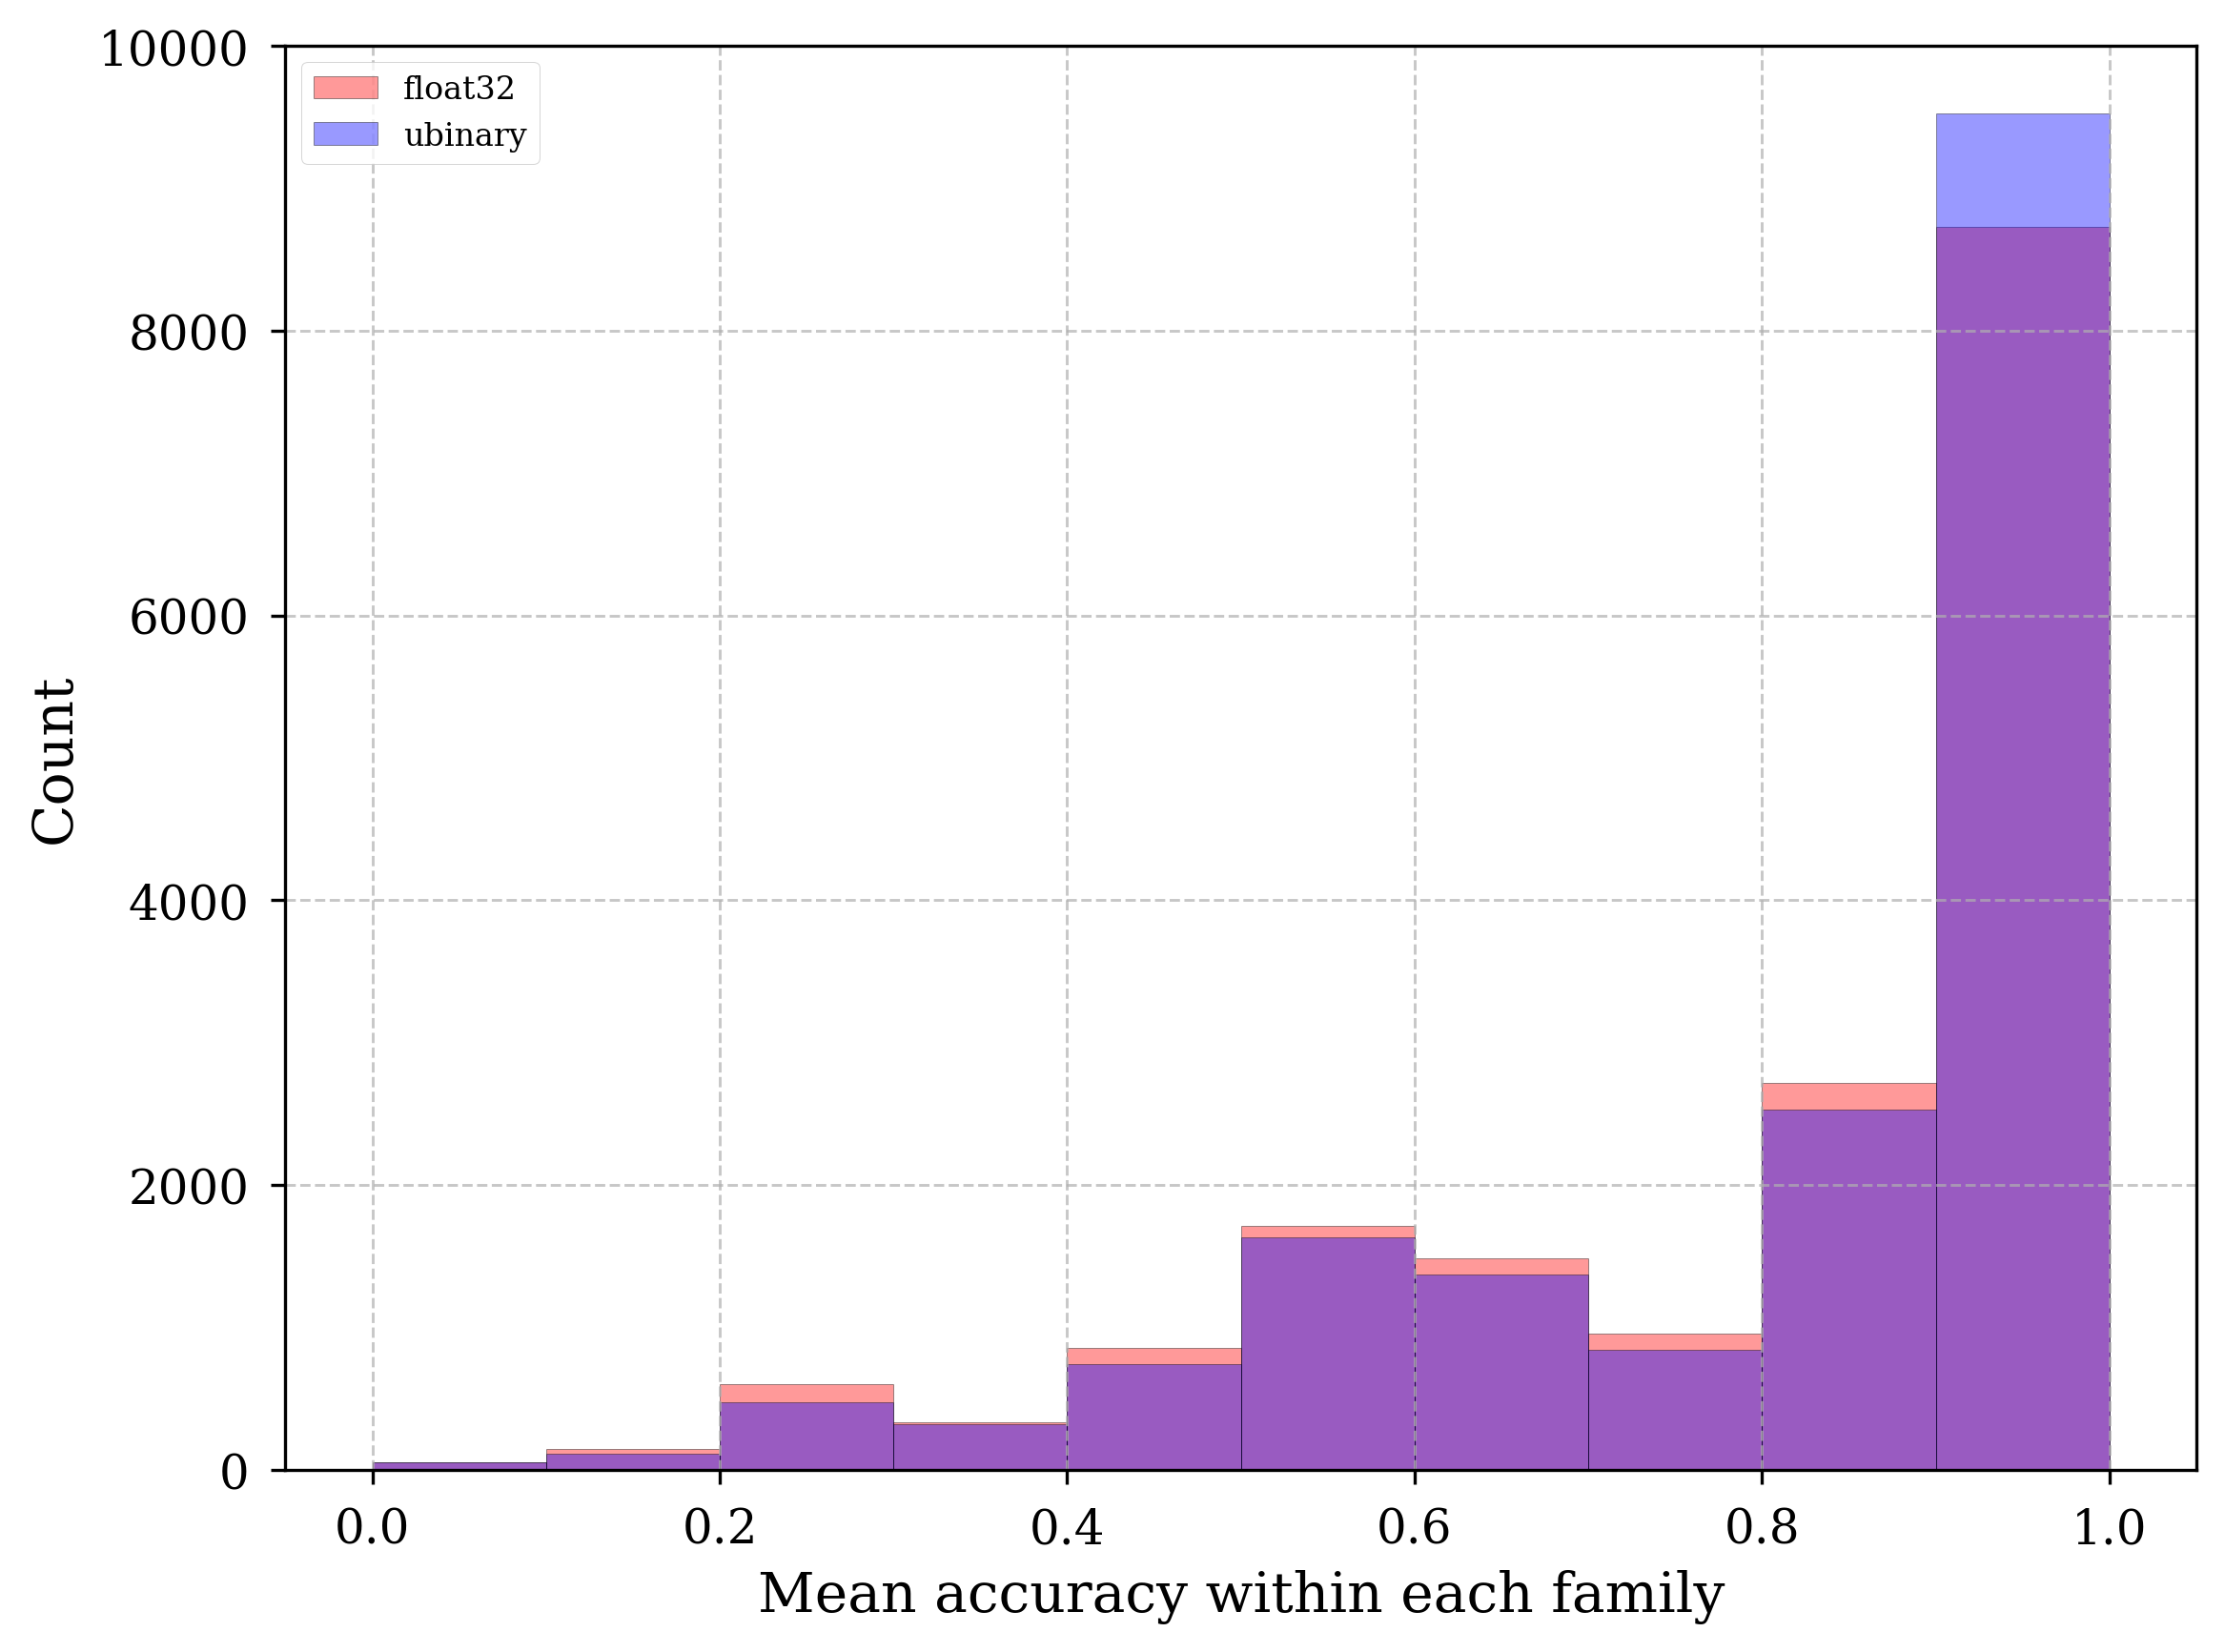

In [40]:
float32_accuracy_values = list(float32_output.accuracy_by_cluster.values())
ubinary_accuracy_values = list(ubinary_output.accuracy_by_cluster.values())

plot_histograms(
    datasets=[float32_accuracy_values, ubinary_accuracy_values],
    labels=['float32', 'ubinary'],
    xlabel='Mean accuracy within each family',
    ylabel='Count',
    bins=10,
    alpha=0.4,
    colors=['red', 'blue'],
)

In [51]:
import requests

class PfamMetadata(BaseModel):
    pfam_id: str = Field(
        ...,
        description='The Pfam ID.'
    )
    name: str = Field(
        ...,
        description='The family name.'
    )
    description: str = Field(
        ...,
        description='The family description.'
    )


def get_pfam_metadata(pfam_id: str) -> PfamMetadata:
    """Query the Interpro API for the name and description of a Pfam ID.

    Parameters
    ----------
    pfam_id: str
        The Pfam ID to query.

    Returns
    -------
    PfamMetadata
        The metadata for the Pfam containing the ID, name, and description.
    """
    # If the Pfam ID contains versioning, remove it
    pfam_id = pfam_id.split('.')[0]
    
    # Query the Interpro API
    url = f'https://www.ebi.ac.uk/interpro/api/entry/pfam/{pfam_id}/'
    response = requests.get(url)
    if response.status_code != 200:
        raise Exception(f'Failed to retrieve data: {response.status_code}')

    # Get the JSON payload
    data = response.json()

    # Get the name
    name = data['metadata']['name']['name']

    # Get the description
    if data['metadata']['description'] is not None:
        description = data['metadata']['description'][0]['text']
    else:
        description = ''

    # Return the metadata
    return PfamMetadata(pfam_id=pfam_id, name=name, description=description)

In [52]:
ranked_worst_to_best = sorted(ubinary_output.accuracy_by_cluster.items(), key=lambda x: x[1])

In [53]:
# Number of families with 100% and 0% accuracy
all_correct = sum(acc==1.0 for family, acc in ranked_worst_to_best)
none_correct = sum(acc==0.0 for family, acc in ranked_worst_to_best)
print(f'All correct: count {all_correct} -- {(all_correct / len(ranked_worst_to_best)) * 100 :.2f}% of families')
print(f'None correct: count {none_correct} -- {(none_correct / len(ranked_worst_to_best)) * 100 :.2f}% of families')

All correct: count 4431 -- 25.18% of families
None correct: count 14 -- 0.08% of families


In [54]:
metadata = [
    get_pfam_metadata(pfam_id)
    for pfam_id, accuracy in tqdm(ranked_worst_to_best)
    if accuracy == 0.0
]

100%|█████████████████████████████████████████████████████████████████████| 17599/17599 [00:06<00:00, 2673.23it/s]


In [46]:
for x in metadata:
    print(x)
    print()

pfam_id='PF00289' name='Biotin carboxylase, N-terminal domain' description='<p>This domain is structurally related to the PreATP-grasp domain. The family contains the N-terminus of biotin carboxylase enzymes [[cite:PUB00000390],[cite:PUB00078719]], and propionyl-CoA carboxylase A chain [[cite:PUB00078720]].</p>'

pfam_id='PF02359' name='Cell division protein 48 (CDC48), N-terminal domain' description='<p>This domain has a double psi-beta barrel fold and includes VCP-like  ATPase and N-ethylmaleimide sensitive fusion protein N-terminal  domains.  Both the VAT and NSF N-terminal functional domains consist of two structural domains of which this is at the N-terminus. The VAT-N domain found in AAA ATPases [pfam:PF00004] is a substrate  185-residue recognition domain [[cite:PUB00007420]].</p>'

pfam_id='PF00036' name='EF hand domain' description='<p>The EF-hands can be divided into two classes: signalling proteins and buffering/transport proteins.  The first group is the largest and include

In [56]:
# TODO: See if all the models perform poorly on a certain subset of Pfams. 
#       Understand why that is, lack of conservation, large families, etc

# TODO: Look get the percent of sequences unique to each family (in the full pfam), 
#       vs those sequences that appear in multiple families. See if this correlates
#       with the accuracy, as a measure of family diversity.

# Analyze ubinary embeddings

In [41]:
from pathlib import Path
import numpy as np
import pandas as pd

from protein_search_evals.search import FaissIndexConfig
from protein_search_evals.search import RetrieverConfig
from protein_search_evals.embed.encoders import Esm2EncoderConfig
from protein_search_evals.embed.encoders import EsmCambrianEncoderConfig
from protein_search_evals.datasets.pfam import Pfam20Dataset

def get_encoder_config(model_name: str) -> EncoderConfigs:
    """Get the encoder configuration.

    Parameters
    ----------
    model_name : str
        The model name to use for the encoder.

    Returns
    -------
    EncoderConfigs
        The encoder configuration.
    """
    if 'esm2' in model_name:
        # Initialize encoder configuration
        encoder_config = Esm2EncoderConfig(
            normalize_embeddings=True,
            pretrained_model_name_or_path=model_name,
        )
        return encoder_config
    elif 'esmc' in model_name:
        # Initialize encoder configuration
        encoder_config = EsmCambrianEncoderConfig(
            normalize_embeddings=True,
            pretrained_model_name_or_path=model_name,
        )
        return encoder_config

    else:
        raise ValueError(f'Unknown encoder: {model_name}')

In [19]:
model_dir = Path('../pfam/embeddings/esm2-650M_pfam20_seed-42/')
model_name = 'facebook/esm2_t33_650M_UR50D'
precision = 'ubinary'
dataset_dir = '../../data/pfam/'

# Get the dataset directory (a single directory named with a UUID
# present in the embeddings directory)
embedding_dataset_dir = next((model_dir / 'embeddings').glob('*'))

# Will automatically create the faiss index if it does not exist
faiss_index_path = model_dir / f'{precision}-faiss.index'

# Initialize FaissIndexConfig
faiss_config = FaissIndexConfig(
    dataset_dir=embedding_dataset_dir,
    faiss_index_path=faiss_index_path,
    precision=precision,
    search_algorithm='exact',
    search_gpus=0,  # Defaults to GPU 0 as relative to CUDA_VISIBLE_DEVICES
)

# Get the encoder configuration
encoder_config = get_encoder_config(model_name)

# Initialize retriever configuration
retriever_config = RetrieverConfig(
    faiss_config=faiss_config,
    encoder_config=encoder_config,
)

# Create the retriever
retriever = retriever_config.get_retriever()

# Load the dataset families
dataset = Pfam20Dataset(dataset_dir)
families = dataset.load_families()

Loading FAISS index from ../pfam/embeddings/esm2-650M_pfam20_seed-42/ubinary-faiss.index
Loading Pfam20 families metadata from ../../data/pfam/pfam20_seed-42/families.json


In [5]:
# Number of sequences in the full dataset
num_sequences = len(retriever.faiss_index.dataset)

# The evaluation is over all sequences
query_keys = np.arange(num_sequences)

# Get all the sequence tags (Uniprot IDs)
query_tags = retriever.get(query_keys, key='tags')

# Get all query embeddings from the index
query_embeddings = retriever.get(query_keys, key='embeddings')
query_embeddings.shape

(351980, 1280)

In [21]:
# The total number of 1s in each ubinary quantized embedding
number_of_ones = np.sum(query_embeddings > 0, axis=1)
# The sparsity of each quantized vector (actually the number of 1s/(total positions) == 1 - sparsity
sparsities = number_of_ones / query_embeddings.shape[1]

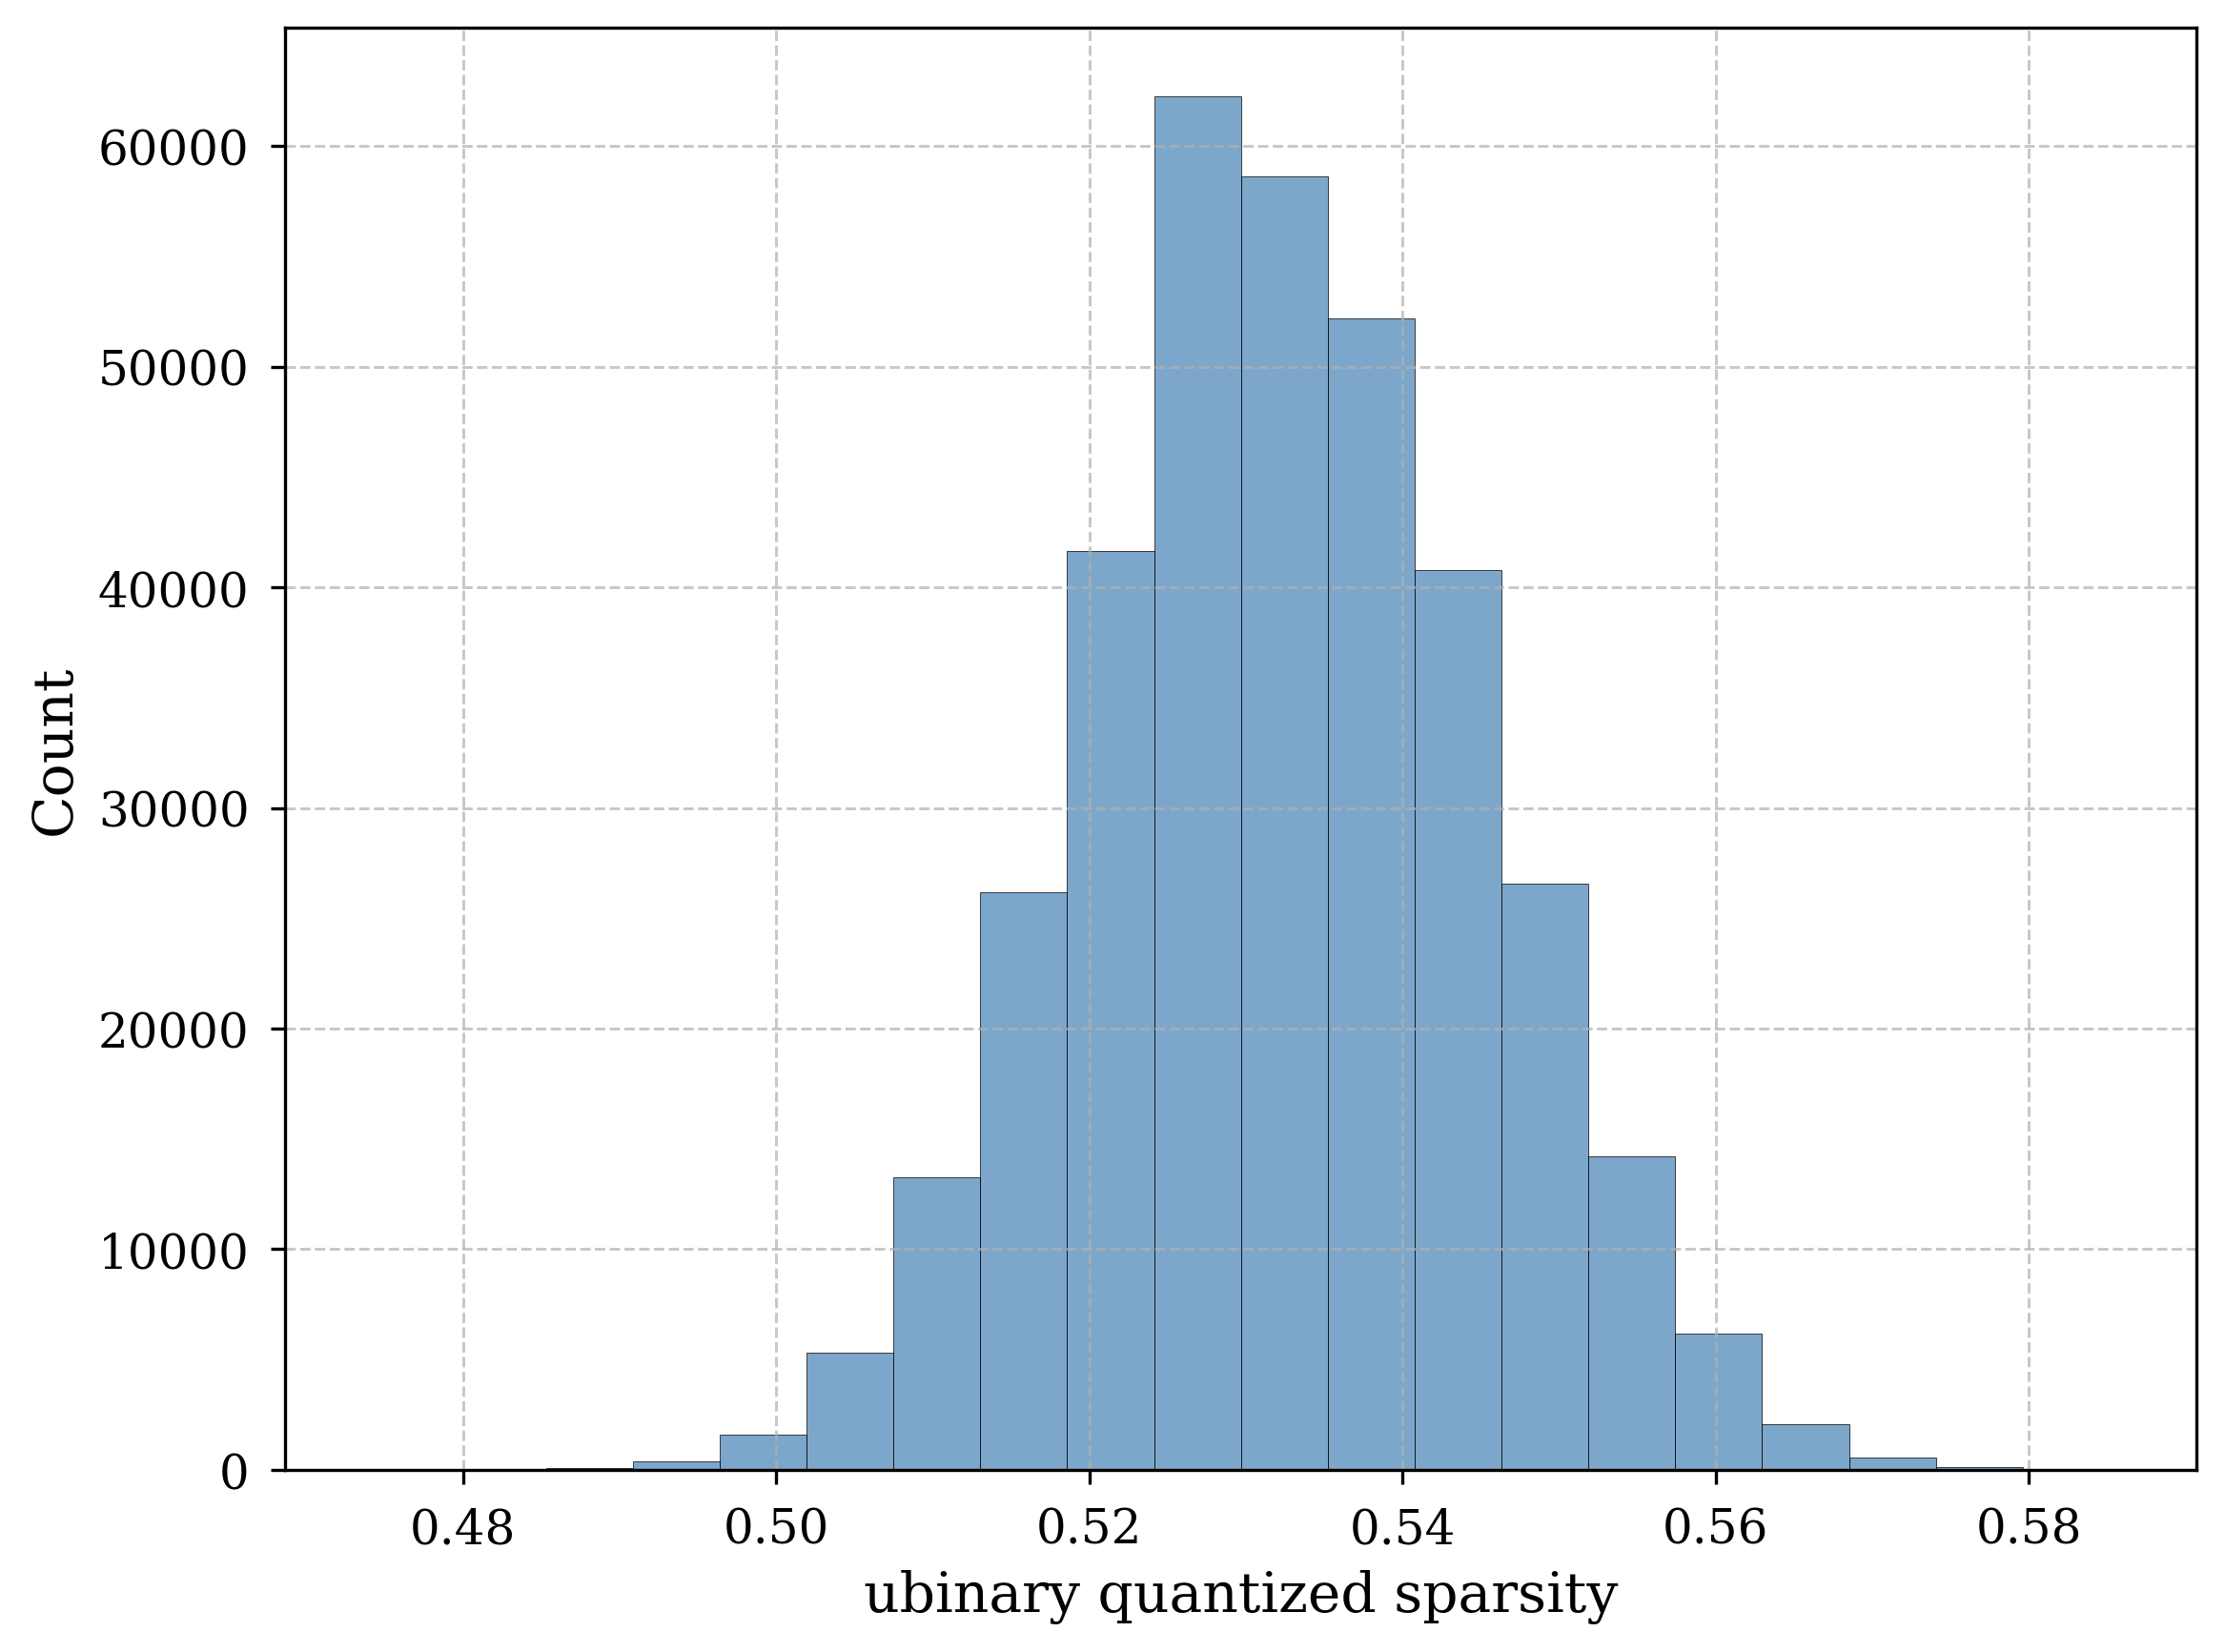

In [22]:
plot_histogram(sparsities, xlabel='ubinary quantized sparsity', ylabel='Count', bins=20)

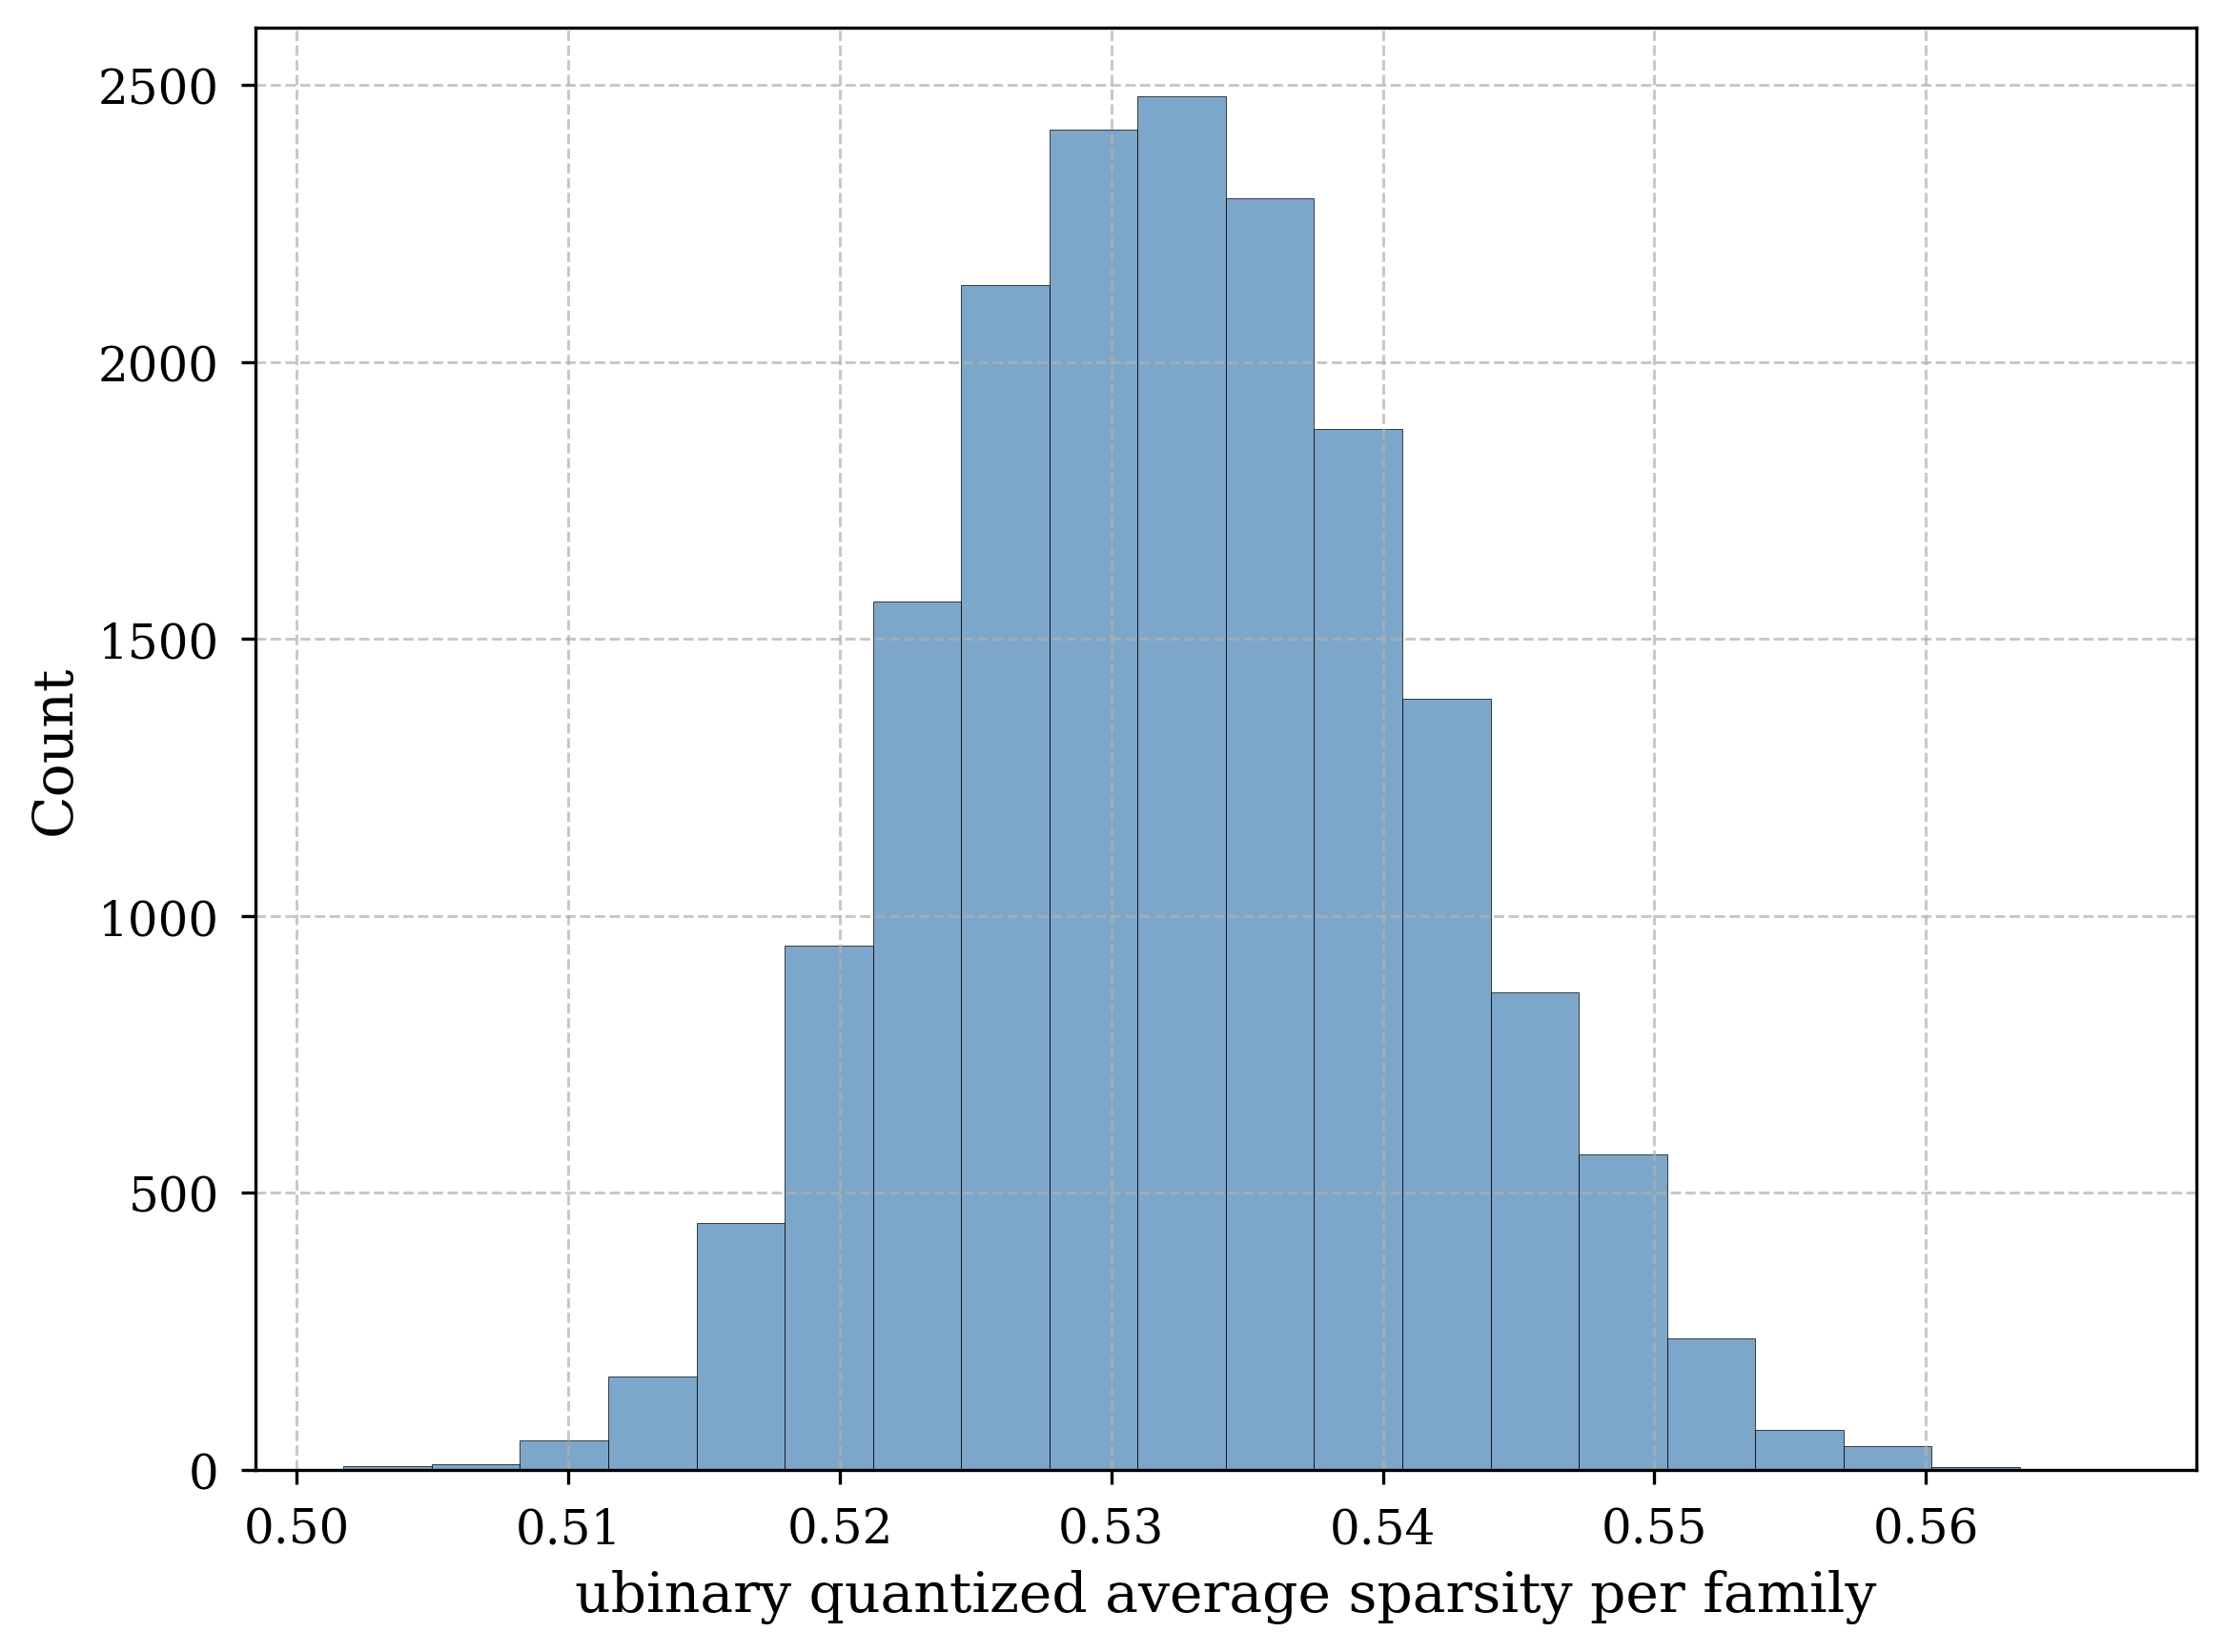

In [33]:
# Plot the average sparsity by family

# Create a mapping from Uniprot ID to sparsity
uid_to_sparsity = {tag: sparsity for tag, sparsity in zip(query_tags, sparsities)}

# Group the sparsities by family
familiy_to_sparsities = {
    pfam_id: [uid_to_sparsity[uid] for uid in uids] 
    for pfam_id, uids in families.items()
}

# Compute the average sparsity per family
avg_sparsity_by_family = {
    pfam_id: float(np.mean(sparsities)) 
    for pfam_id, sparsities in familiy_to_sparsities.items()
}

# Gather each families average sparsity in a list
avg_sparsities = list(avg_sparsity_by_family.values())

# Plot the average sparsity by family
plot_histogram(avg_sparsities, xlabel='ubinary quantized average sparsity per family', ylabel='Count', bins=20)

In [40]:
# Get the accuracy data
output = EvaluatorOutput.from_json('evaluations/reports/report_esm2_t33_650M_UR50D_ubinary_output.json')

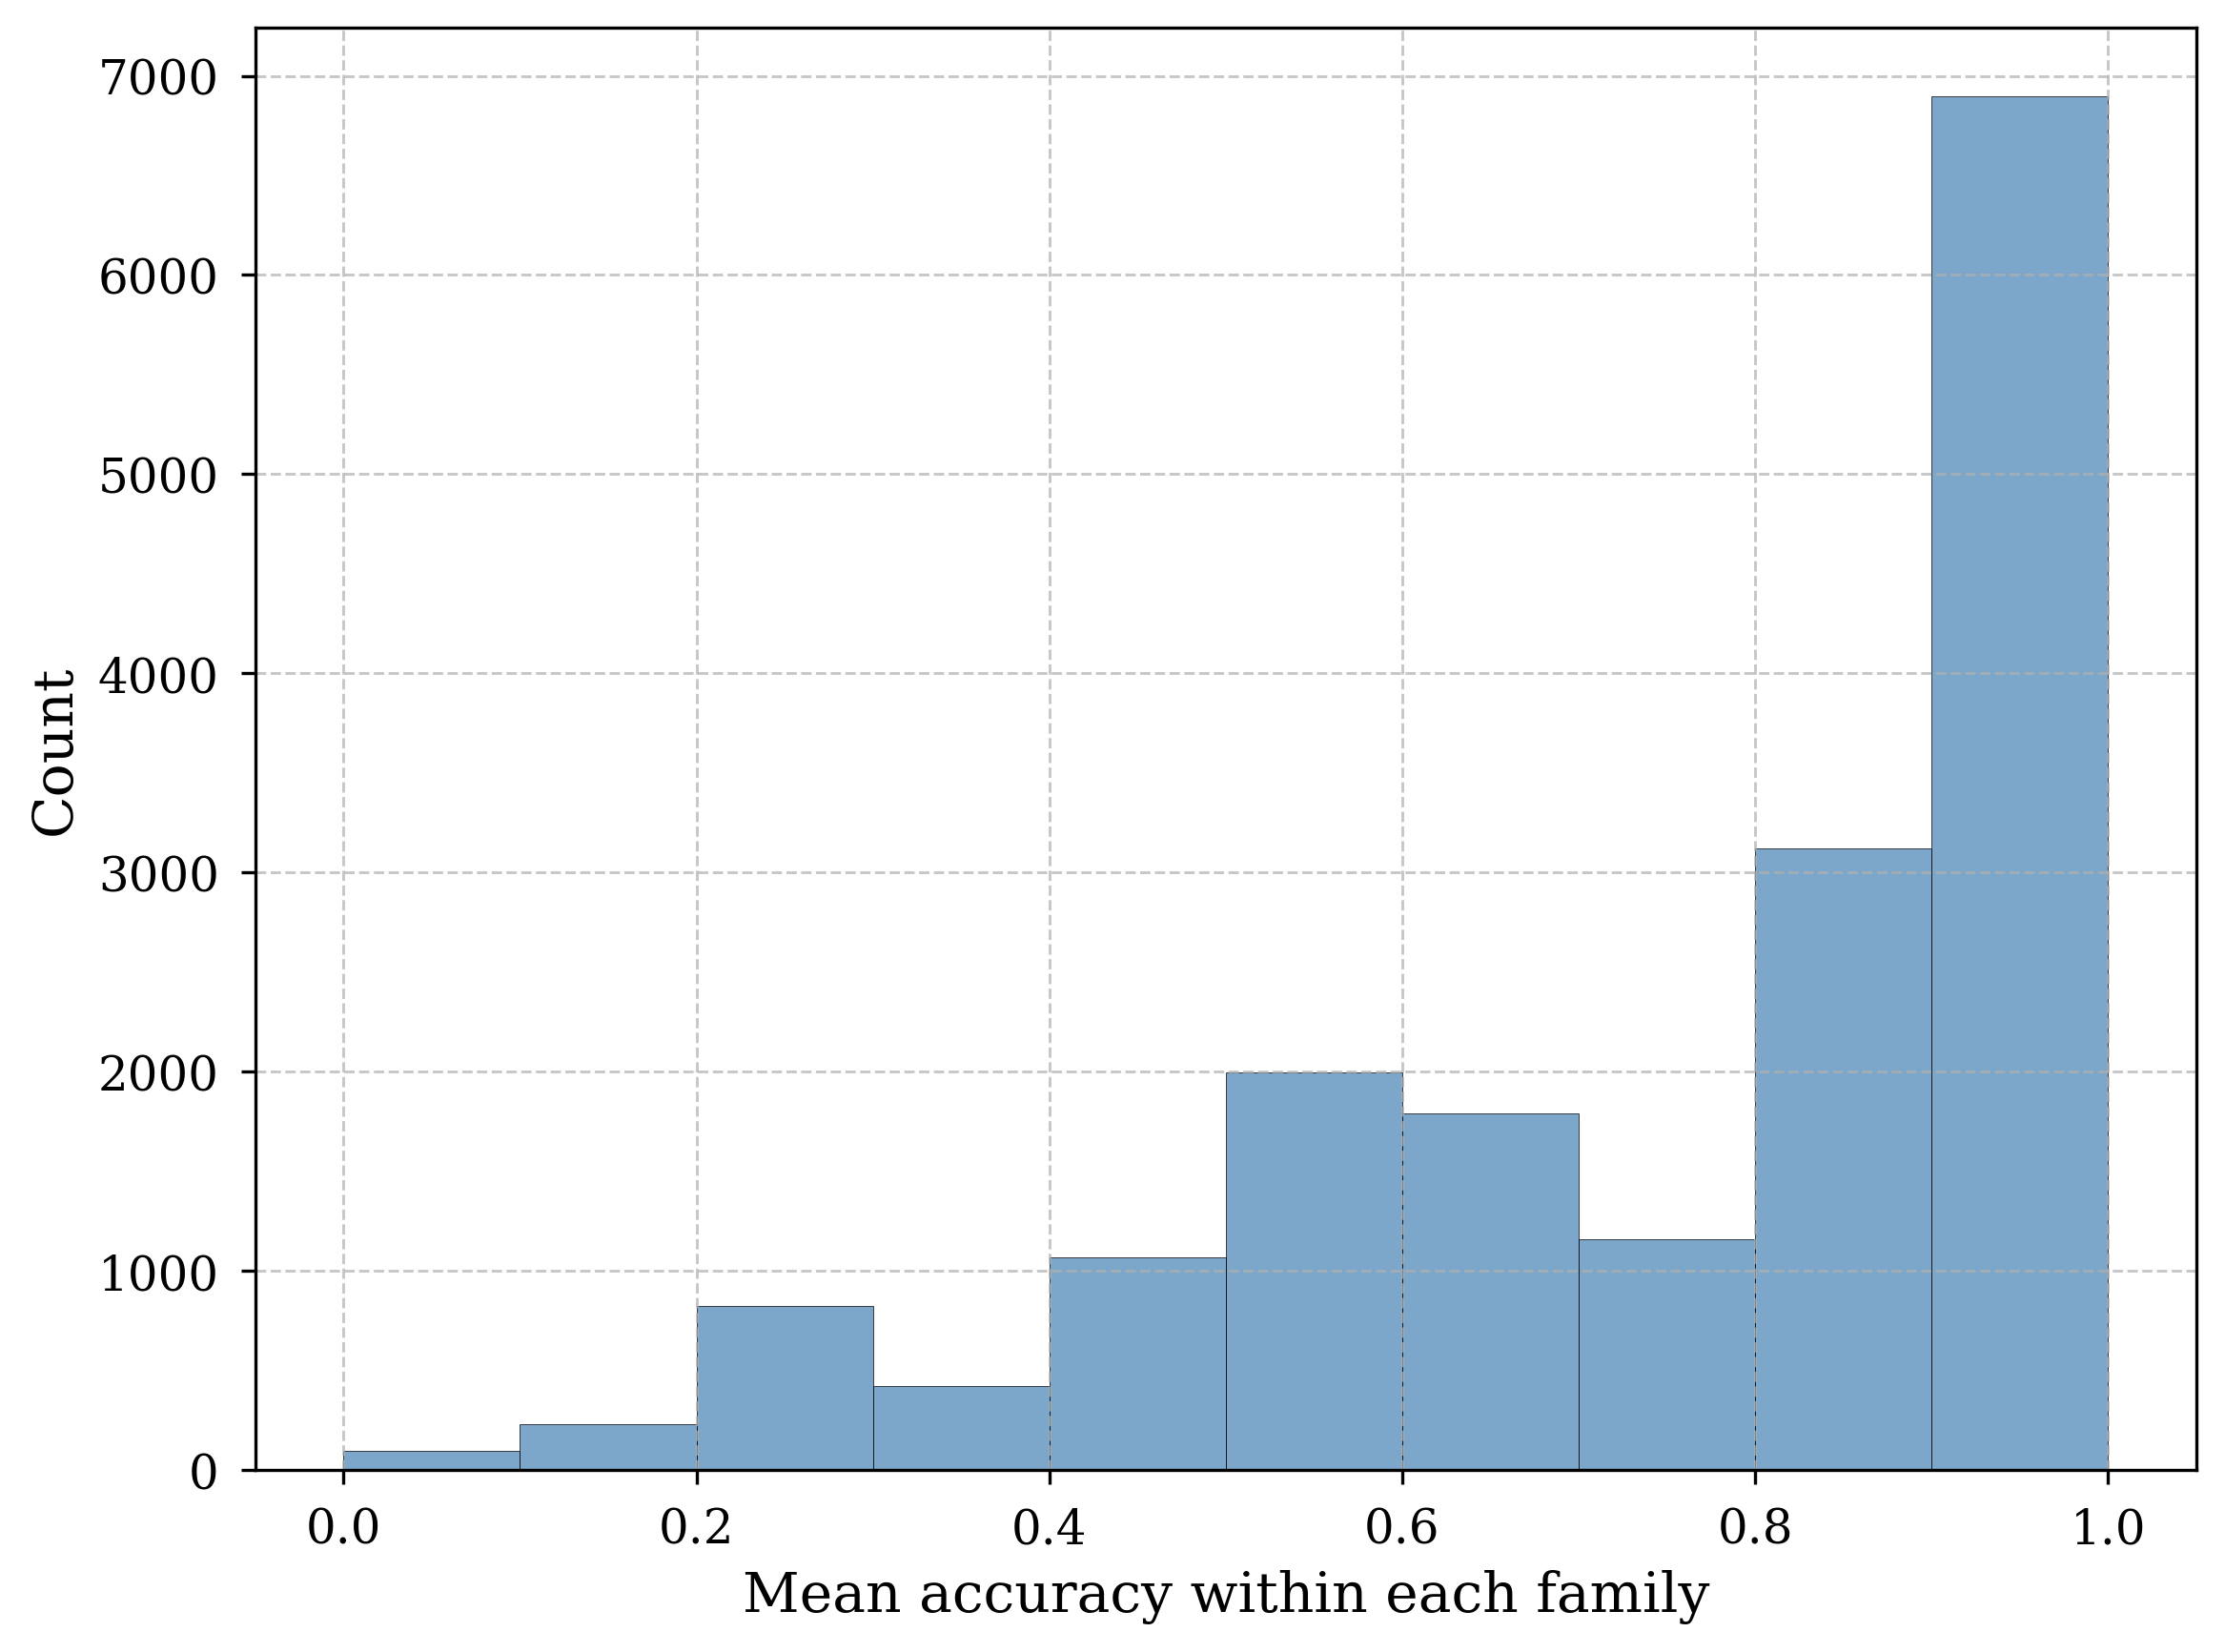

In [43]:
# Plot the accuracies by family
accuracy_values = list(output.accuracy_by_family.values())
plot_histogram(accuracy_values, xlabel='Mean accuracy within each family', ylabel='Count', bins=10)

In [46]:
df = pd.DataFrame({'mean_accuracy': accuracy_values, 'mean_sparsity': avg_sparsities})
df.corr()
# Take away: accuracy not correlated with sparsity

,mean_accuracy,mean_sparsity
mean_accuracy,1.000000,0.032011
mean_sparsity,0.032011,1.000000


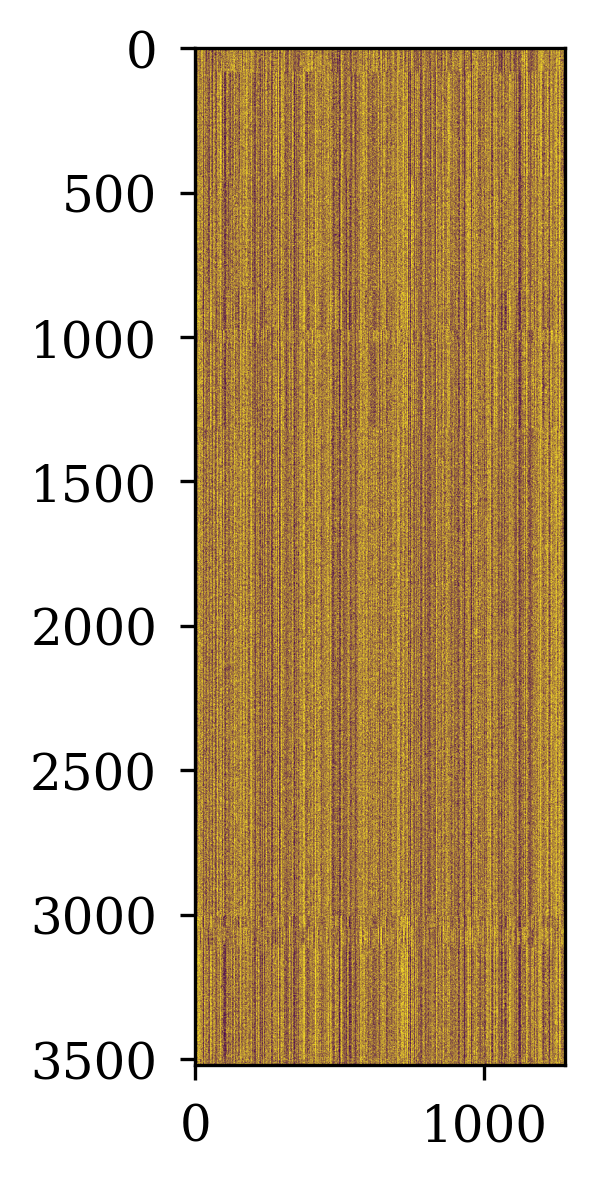

In [54]:
# Plot the binary vectors
import matplotlib.pyplot as plt

plt.imshow((query_embeddings > 0).astype(np.float16)[::100])

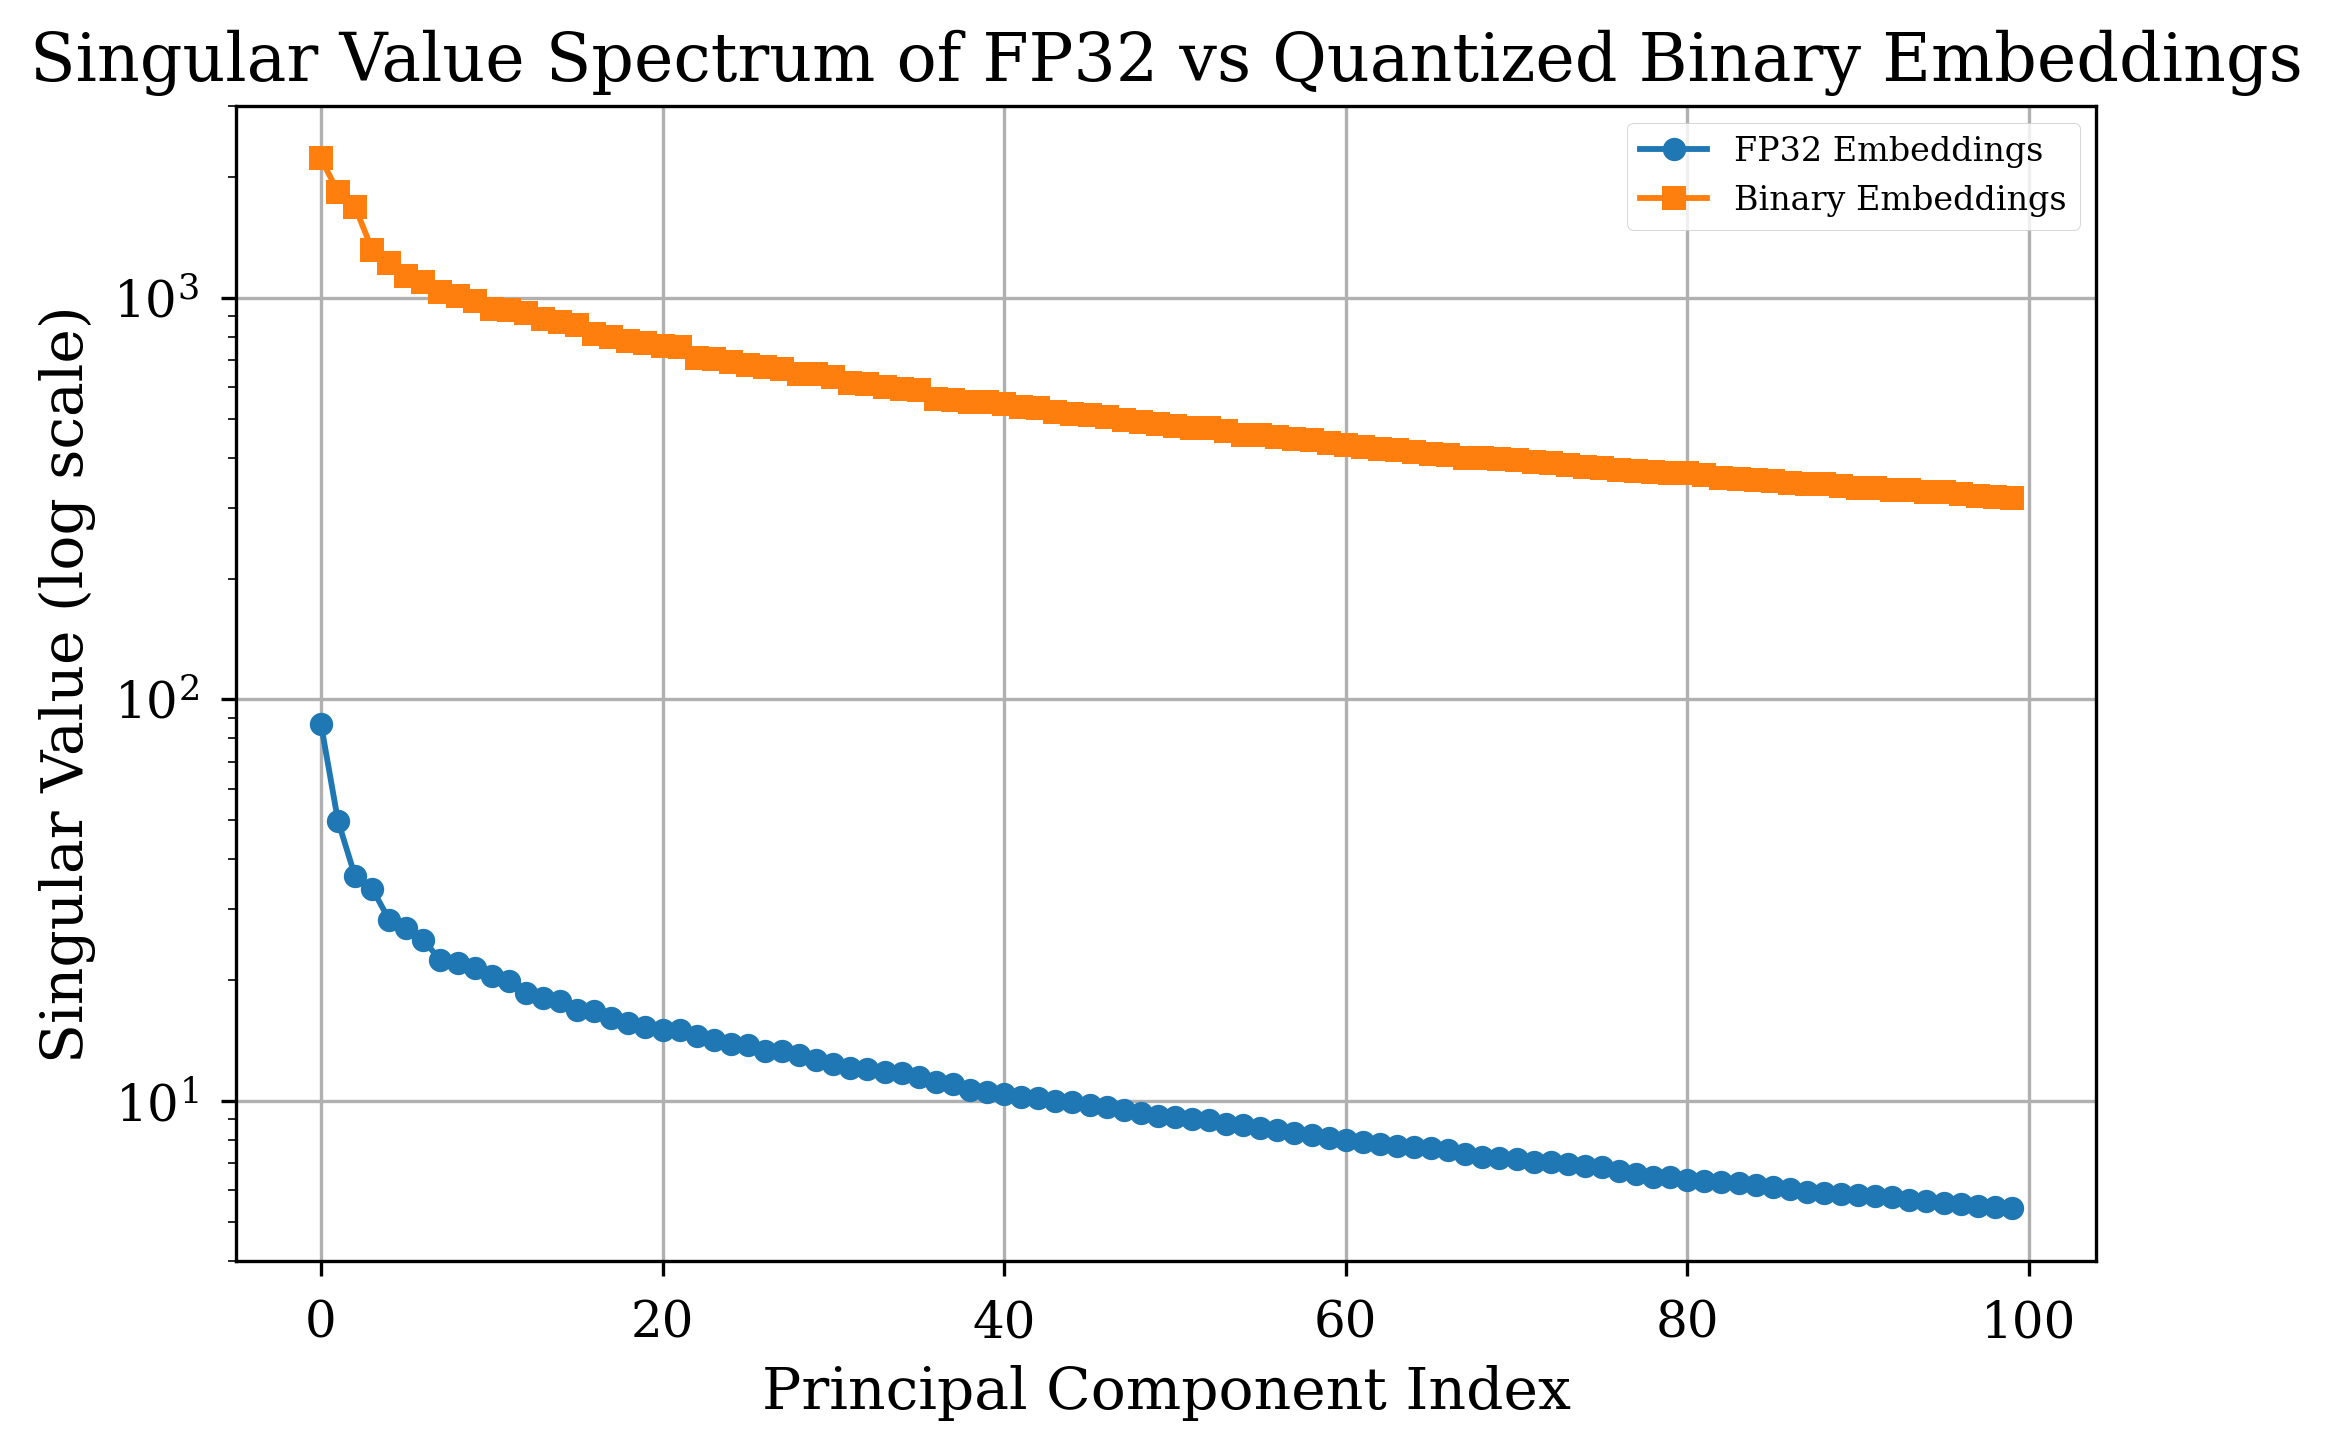

In [55]:
# Compare the spectrum from ubinary to float32

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# fp32_embeddings: (N, D) float32 array
# binary_embeddings: (N, D) uint8 array representing binary vectors
def compute_pca_spectrum(embeddings, n_components=100):
    """Computes PCA and returns the singular values (spectrum)."""
    pca = PCA(n_components=n_components)
    pca.fit(embeddings)
    return pca.singular_values_

# Example: Replace with actual embeddings
fp32_embeddings = query_embeddings
binary_embeddings = (query_embeddings > 0).astype(np.float32)

# Compute PCA singular value spectra
fp32_spectrum = compute_pca_spectrum(fp32_embeddings)
binary_spectrum = compute_pca_spectrum(binary_embeddings)

# Plot the singular value spectrum
plt.figure(figsize=(8, 5))
plt.plot(fp32_spectrum, label='FP32 Embeddings', marker='o')
plt.plot(binary_spectrum, label='Binary Embeddings', marker='s')
plt.yscale('log')  # Log scale to emphasize differences
plt.xlabel("Principal Component Index")
plt.ylabel("Singular Value (log scale)")
plt.title("Singular Value Spectrum of FP32 vs Quantized Binary Embeddings")
plt.legend()
plt.grid(True)
plt.show()

In [57]:
fp32_norm = np.mean(np.linalg.norm(fp32_embeddings, axis=1))
binary_norm = np.mean(np.linalg.norm(binary_embeddings, axis=1))

fp32_norm, binary_norm

(1.0, 26.107538)

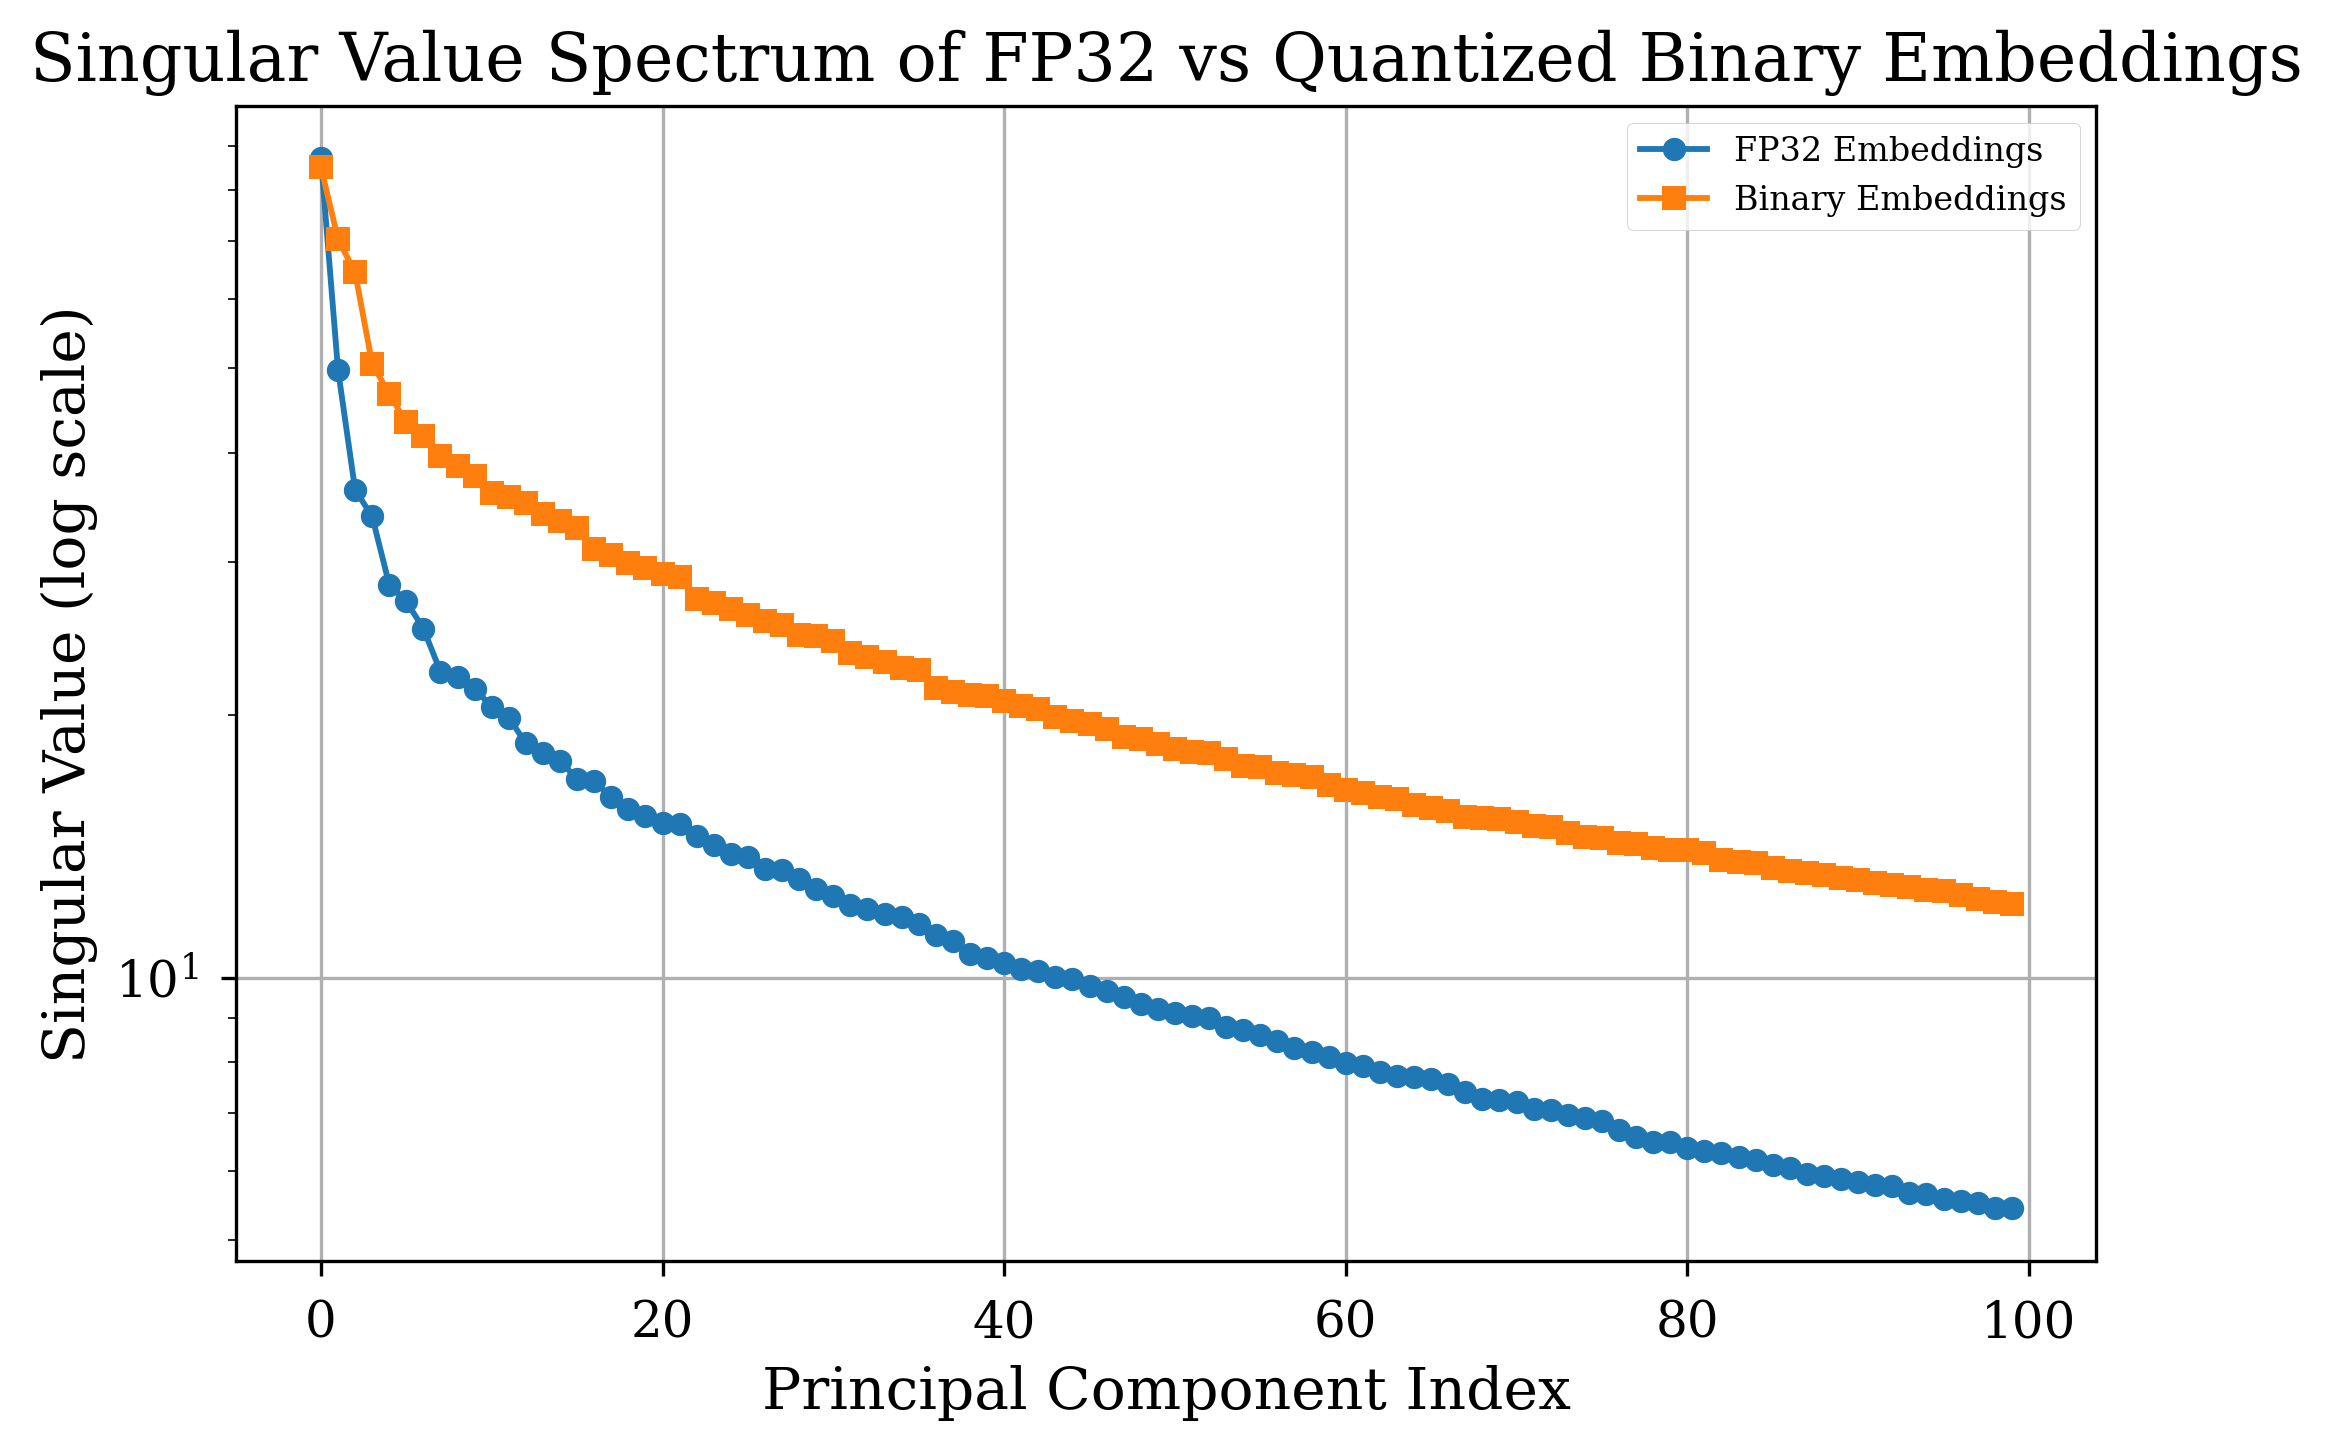

In [59]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# fp32_embeddings: (N, D) float32 array
# binary_embeddings: (N, D) uint8 array representing binary vectors
def compute_pca_spectrum(embeddings, n_components=100):
    """Computes PCA and returns the singular values (spectrum)."""
    pca = PCA(n_components=n_components)
    pca.fit(embeddings)
    return pca.singular_values_

# Get the fp32 and binary embeddings
fp32_embeddings = query_embeddings
binary_embeddings = (query_embeddings > 0).astype(np.float32)

# Normalize the binary embeddings (fp32 embeddings are pre-normalized)
binary_embeddings = binary_embeddings / np.linalg.norm(binary_embeddings, axis=1, keepdims=True)

# Compute PCA singular value spectra
fp32_spectrum = compute_pca_spectrum(fp32_embeddings)
binary_spectrum = compute_pca_spectrum(binary_embeddings)

# Plot the singular value spectrum
plt.figure(figsize=(8, 5))
plt.plot(fp32_spectrum, label='FP32 Embeddings', marker='o')
plt.plot(binary_spectrum, label='Binary Embeddings', marker='s')
plt.yscale('log')  # Log scale to emphasize differences
plt.xlabel("Principal Component Index")
plt.ylabel("Singular Value (log scale)")
plt.title("Singular Value Spectrum of FP32 vs Quantized Binary Embeddings")
plt.legend()
plt.grid(True)
plt.show()

In [60]:
fp32_norm = np.mean(np.linalg.norm(fp32_embeddings, axis=1))
binary_norm = np.mean(np.linalg.norm(binary_embeddings, axis=1))

fp32_norm, binary_norm

(1.0, 1.0)

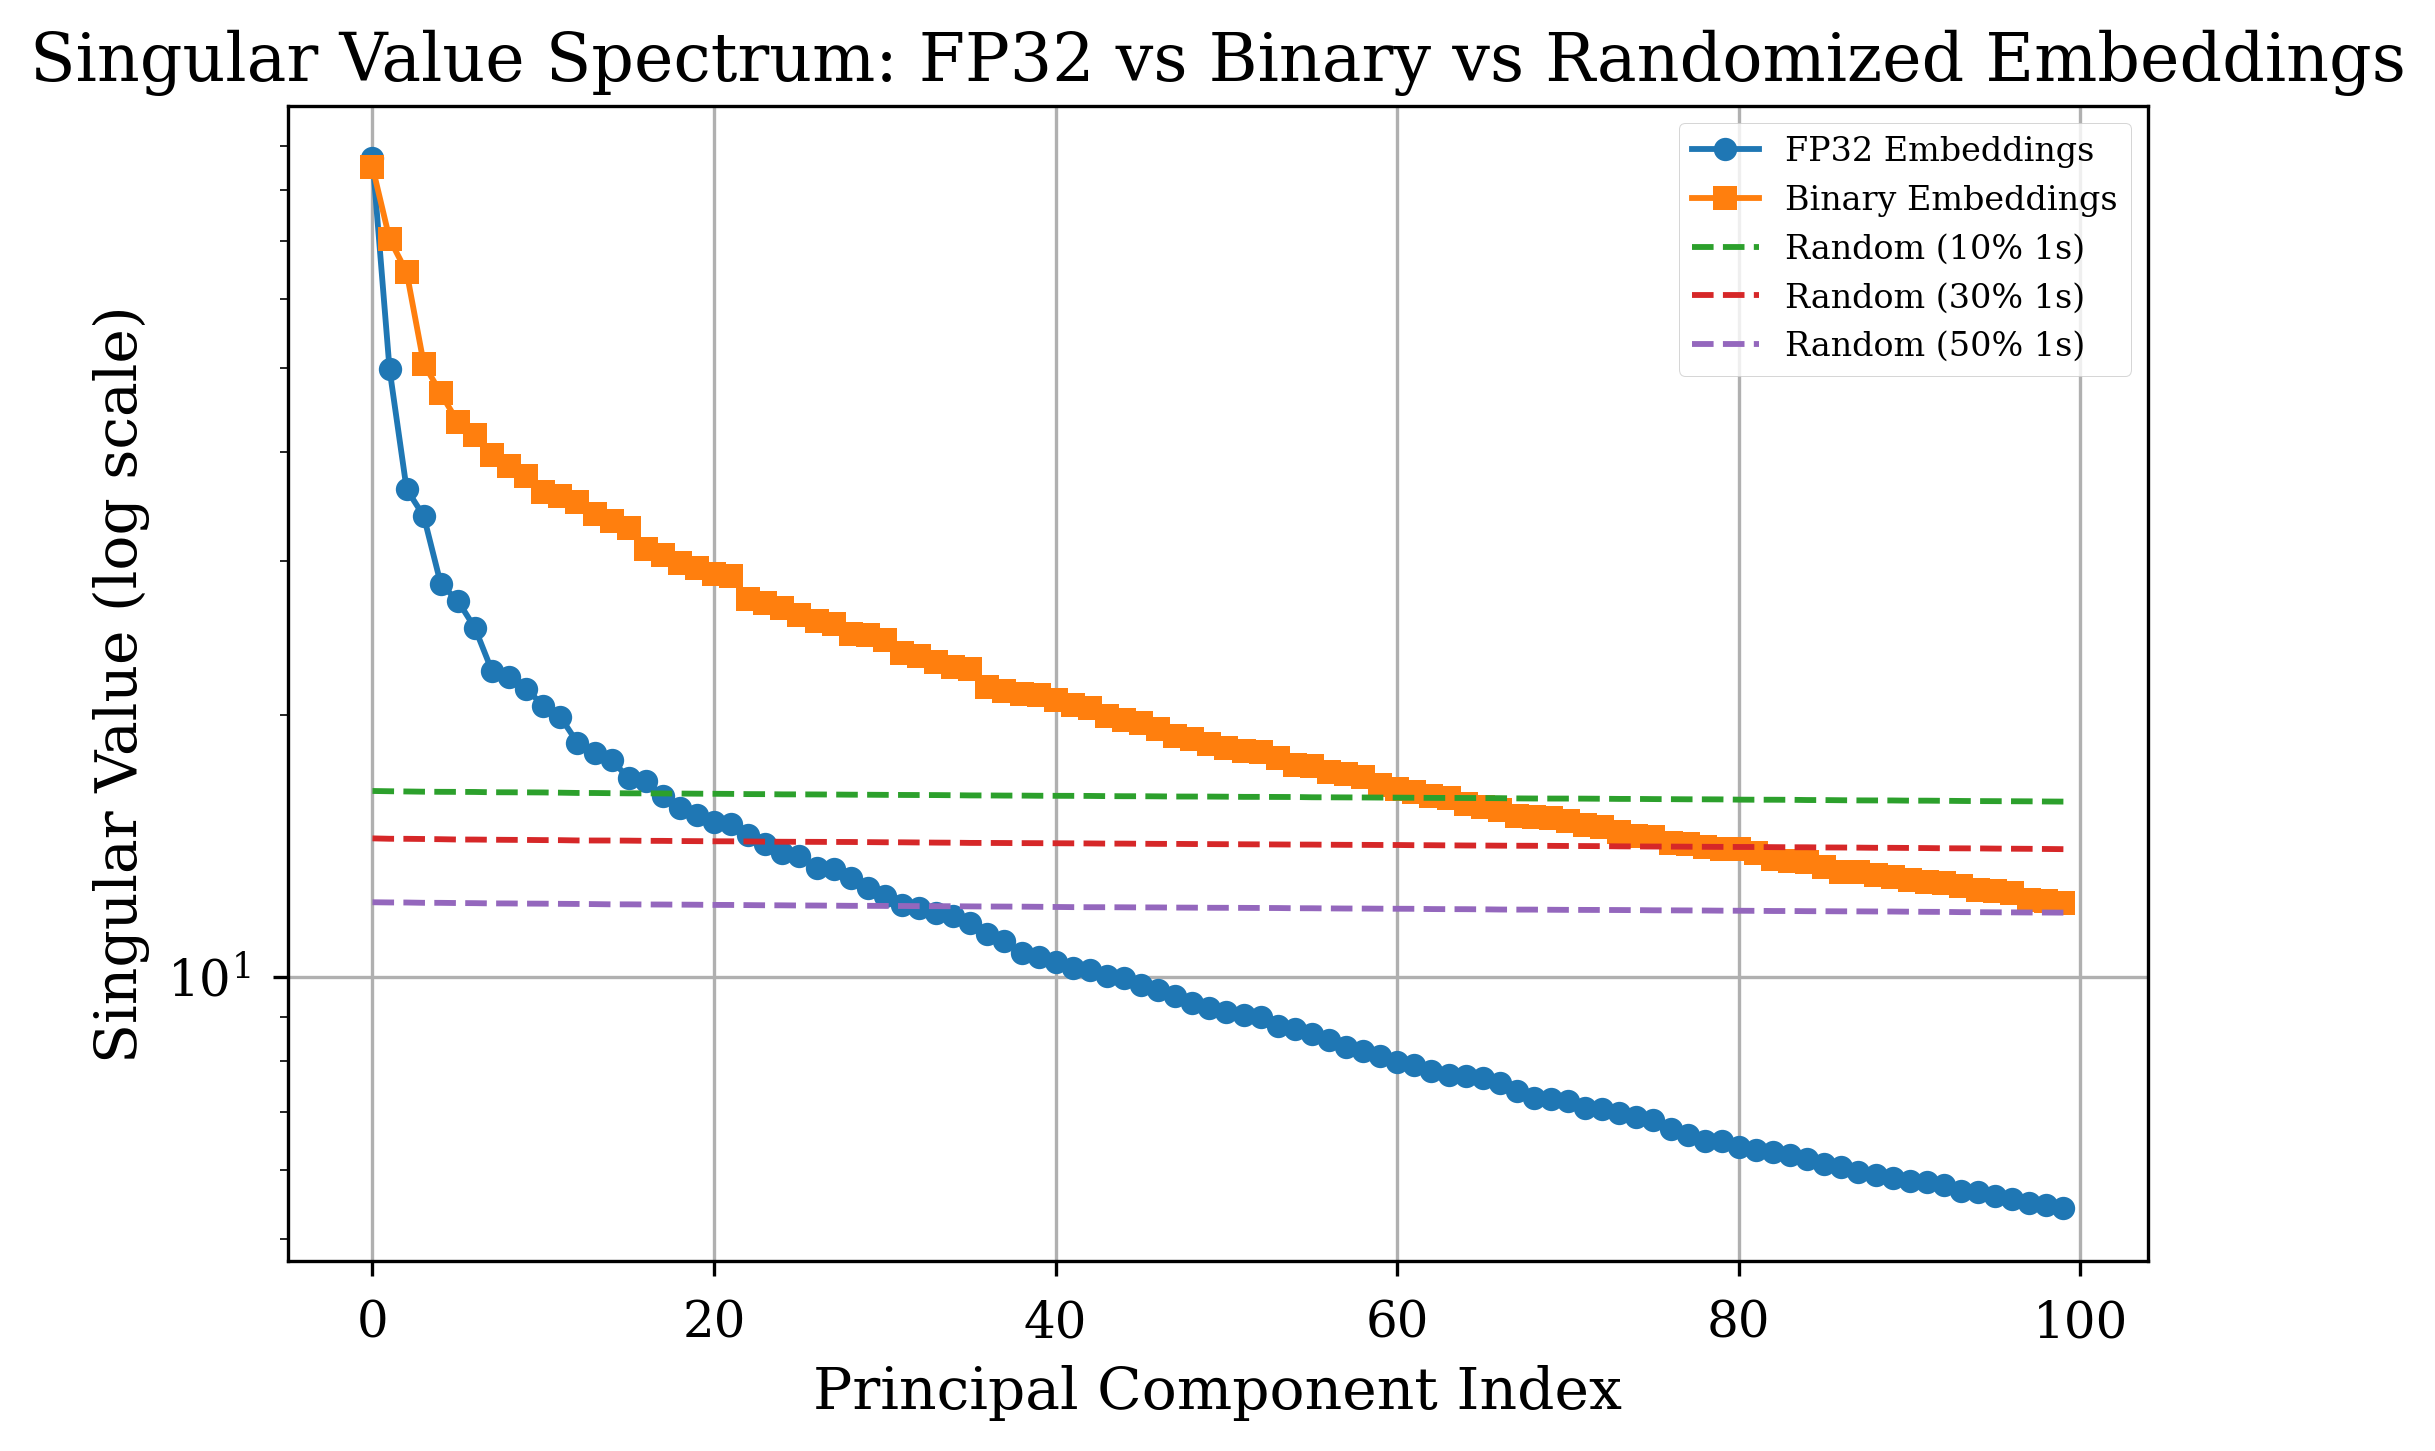

In [61]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# fp32_embeddings: (N, D) float32 array
# binary_embeddings: (N, D) uint8 array representing binary vectors
def compute_pca_spectrum(embeddings, n_components=100):
    """Computes PCA and returns the singular values (spectrum)."""
    pca = PCA(n_components=n_components)
    pca.fit(embeddings)
    return pca.singular_values_

# Get the fp32 and binary embeddings
fp32_embeddings = query_embeddings
binary_embeddings = (query_embeddings > 0).astype(np.float32)

N, D = binary_embeddings.shape
random_binary_10 = np.random.choice([0, 1], size=(N, D), p=[0.9, 0.1]).astype(np.float32)  # 10% 1s
random_binary_30 = np.random.choice([0, 1], size=(N, D), p=[0.7, 0.3]).astype(np.float32)  # 30% 1s
random_binary_50 = np.random.choice([0, 1], size=(N, D), p=[0.5, 0.5]).astype(np.float32)  # 50% 1s

# Normalize all embeddings (fp32 pre-normalized)
binary_embeddings /= np.linalg.norm(binary_embeddings, axis=1, keepdims=True) + 1e-8
random_binary_10 /= np.linalg.norm(random_binary_10, axis=1, keepdims=True) + 1e-8
random_binary_30 /= np.linalg.norm(random_binary_30, axis=1, keepdims=True) + 1e-8
random_binary_50 /= np.linalg.norm(random_binary_50, axis=1, keepdims=True) + 1e-8

# Compute PCA singular value spectra
fp32_spectrum = compute_pca_spectrum(fp32_embeddings)
binary_spectrum = compute_pca_spectrum(binary_embeddings)
random_10_spectrum = compute_pca_spectrum(random_binary_10)
random_30_spectrum = compute_pca_spectrum(random_binary_30)
random_50_spectrum = compute_pca_spectrum(random_binary_50)

# Plot the singular value spectrum
plt.figure(figsize=(8, 5))
plt.plot(fp32_spectrum, label='FP32 Embeddings', marker='o')
plt.plot(binary_spectrum, label='Binary Embeddings', marker='s')
plt.plot(random_10_spectrum, label='Random (10% 1s)', linestyle='dashed')
plt.plot(random_30_spectrum, label='Random (30% 1s)', linestyle='dashed')
plt.plot(random_50_spectrum, label='Random (50% 1s)', linestyle='dashed')
plt.yscale('log')  # Log scale to emphasize differences
plt.xlabel("Principal Component Index")
plt.ylabel("Singular Value (log scale)")
plt.title("Singular Value Spectrum: FP32 vs Binary vs Randomized Embeddings")
plt.legend()
plt.grid(True)
plt.show()

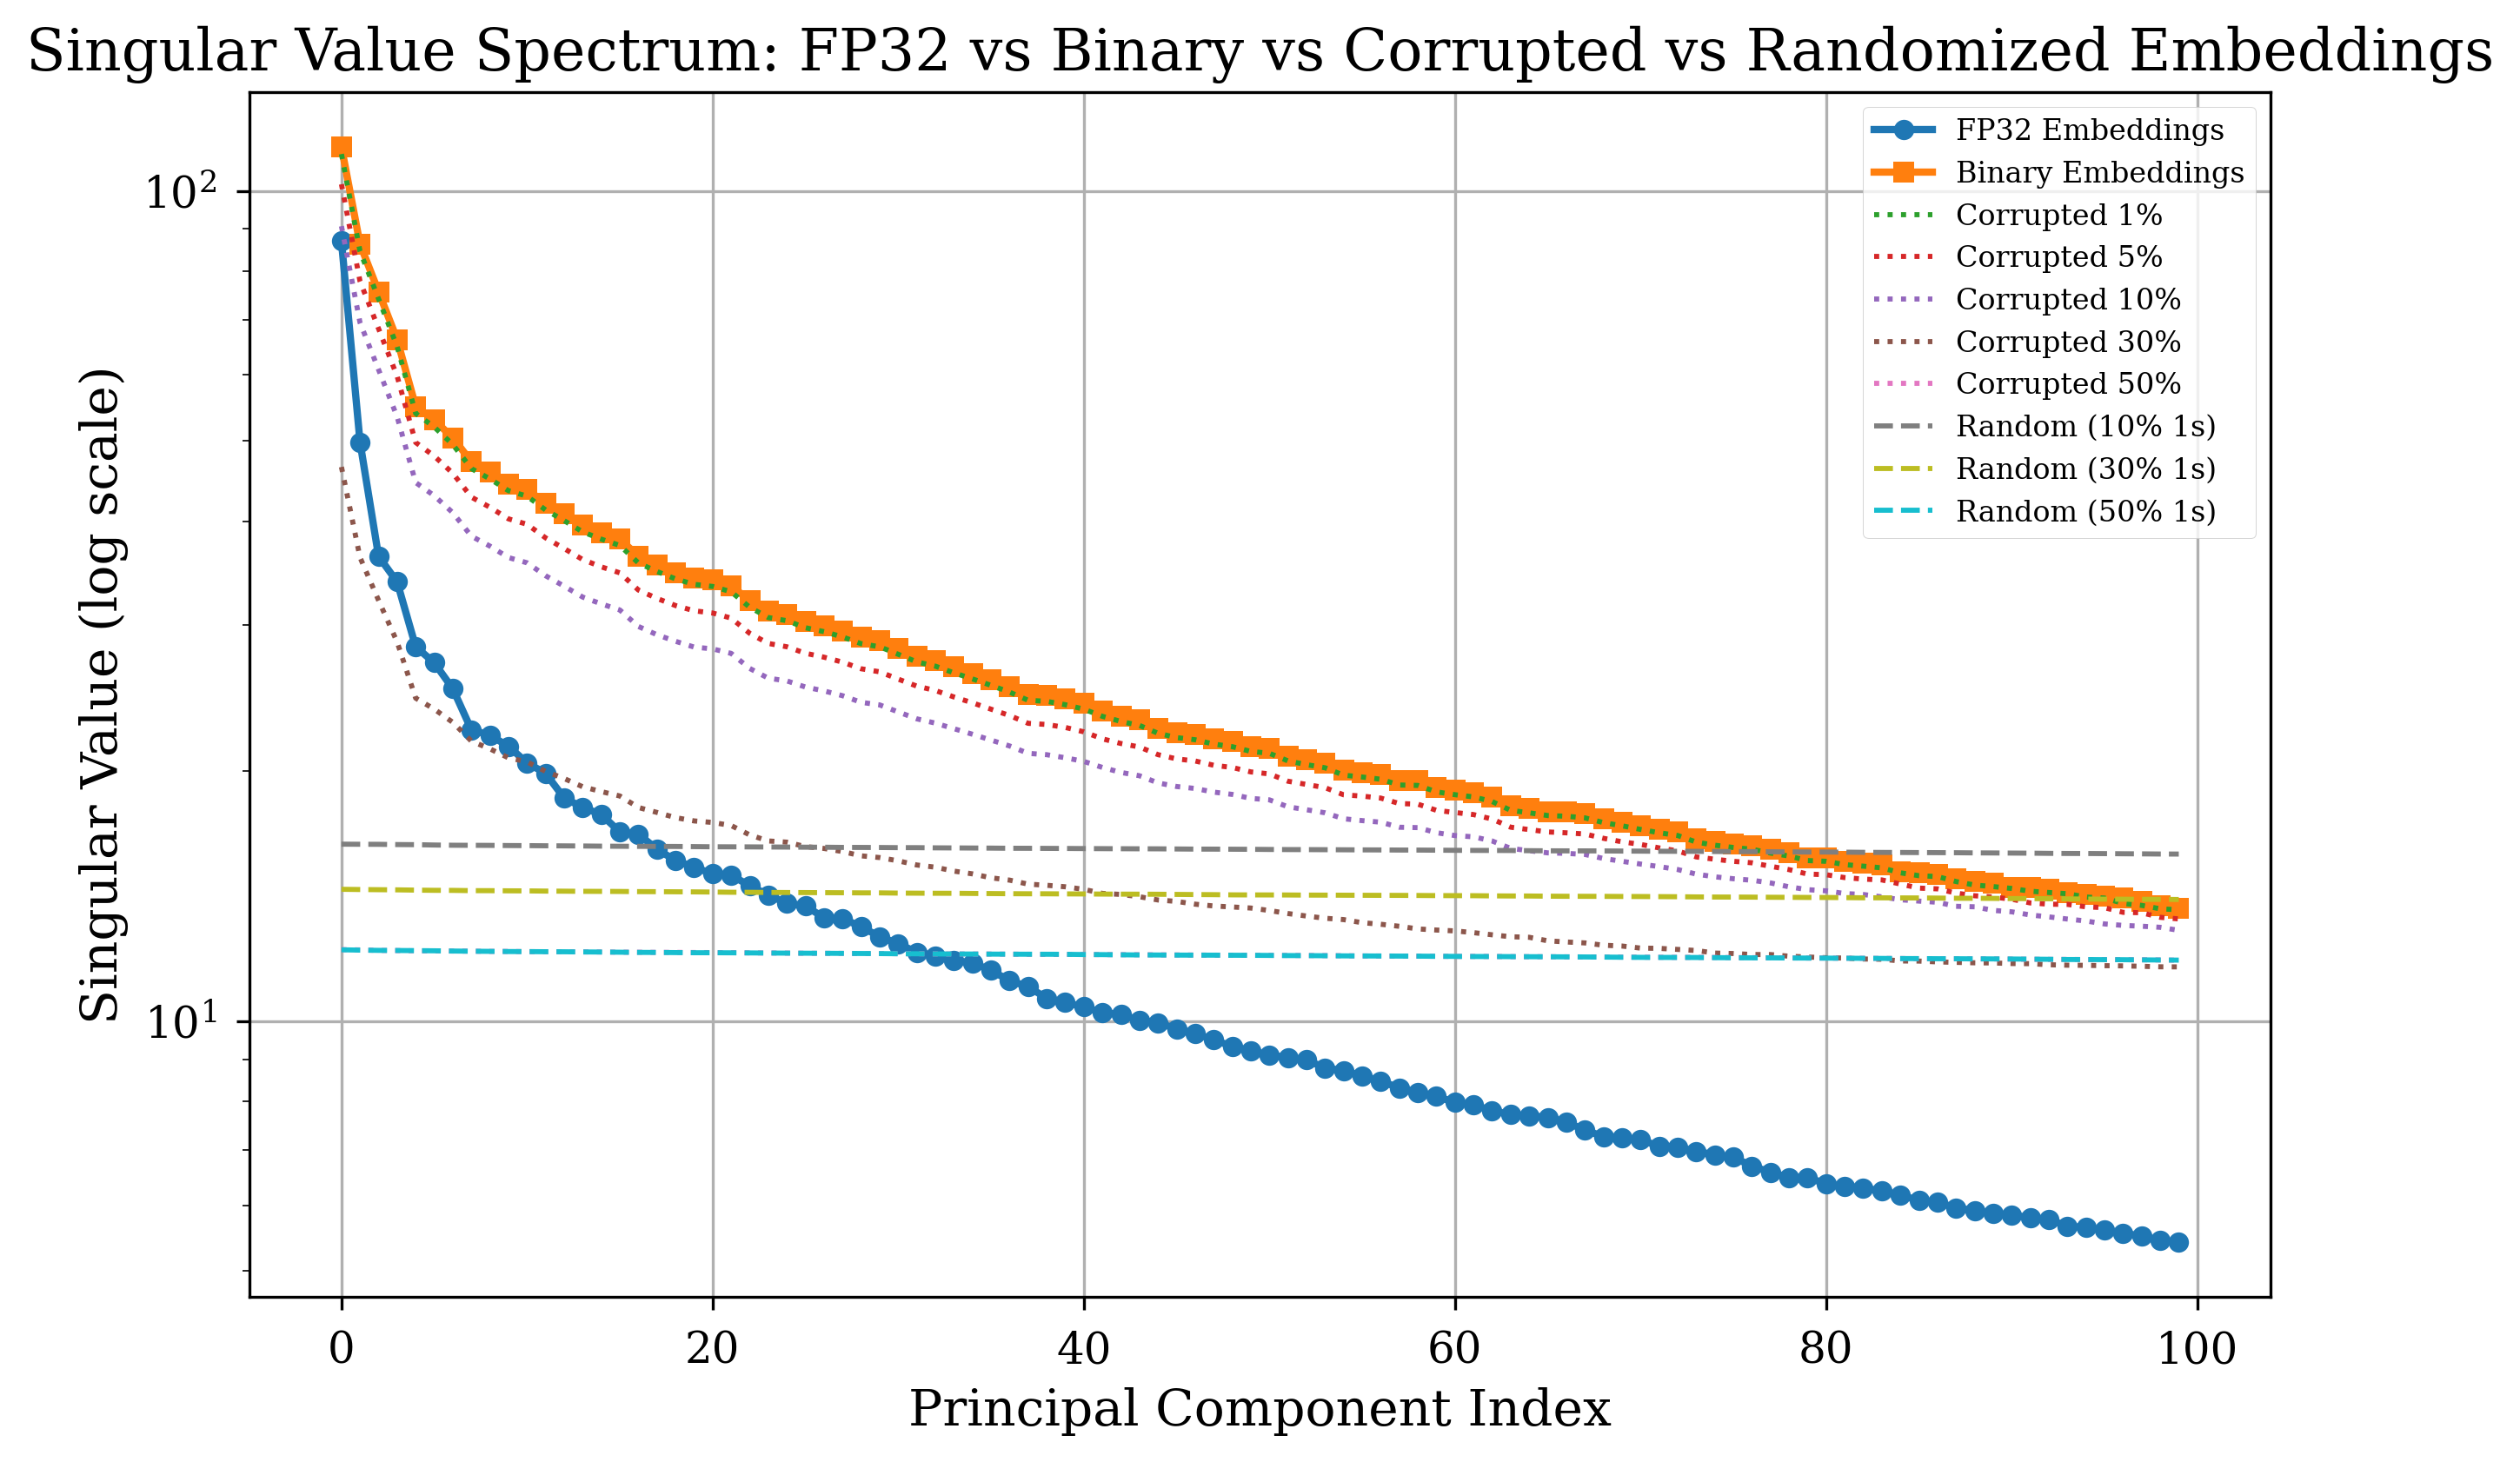

In [64]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def compute_pca_spectrum(embeddings, n_components=100):
    """Computes PCA and returns the singular values (spectrum)."""
    pca = PCA(n_components=n_components)
    pca.fit(embeddings)
    return pca.singular_values_


def corrupt_binary_embeddings(binary_embeddings, corruption_prob):
    """Randomly flips bits in binary embeddings with given corruption probability."""
    noise = np.random.rand(*binary_embeddings.shape) < corruption_prob  # Boolean mask for flips
    return np.abs(binary_embeddings - noise).astype(np.float32)  # Flip bits

# Get the fp32 and binary embeddings
fp32_embeddings = query_embeddings  # (N, D) float32
binary_embeddings = (query_embeddings > 0).astype(np.float32)  # Convert to binary

# Generate corrupted versions of binary embeddings
corrupted_01 = corrupt_binary_embeddings(binary_embeddings, 0.01)  # 1% bit flips
corrupted_05 = corrupt_binary_embeddings(binary_embeddings, 0.05)  # 5% bit flips
corrupted_10 = corrupt_binary_embeddings(binary_embeddings, 0.1)  # 10% bit flips
corrupted_30 = corrupt_binary_embeddings(binary_embeddings, 0.3)  # 30% bit flips
corrupted_50 = corrupt_binary_embeddings(binary_embeddings, 0.5)  # 50% bit flips

# Generate purely random binary embeddings with different flip probabilities
N, D = binary_embeddings.shape
random_binary_10 = np.random.choice([0, 1], size=(N, D), p=[0.9, 0.1]).astype(np.float32)  # 10% 1s
random_binary_30 = np.random.choice([0, 1], size=(N, D), p=[0.7, 0.3]).astype(np.float32)  # 30% 1s
random_binary_50 = np.random.choice([0, 1], size=(N, D), p=[0.5, 0.5]).astype(np.float32)  # 50% 1s

# Normalize all embeddings
def normalize_embeddings(embeddings):
    return embeddings / (np.linalg.norm(embeddings, axis=1, keepdims=True) + 1e-8)

#fp32_embeddings = normalize_embeddings(fp32_embeddings)
binary_embeddings = normalize_embeddings(binary_embeddings)
corrupted_01 = normalize_embeddings(corrupted_01)
corrupted_05 = normalize_embeddings(corrupted_05)
corrupted_10 = normalize_embeddings(corrupted_10)
corrupted_30 = normalize_embeddings(corrupted_30)
corrupted_50 = normalize_embeddings(corrupted_50)
random_binary_10 = normalize_embeddings(random_binary_10)
random_binary_30 = normalize_embeddings(random_binary_30)
random_binary_50 = normalize_embeddings(random_binary_50)

# Compute PCA singular value spectra
fp32_spectrum = compute_pca_spectrum(fp32_embeddings)
binary_spectrum = compute_pca_spectrum(binary_embeddings)
corrupted_01_spectrum = compute_pca_spectrum(corrupted_01)
corrupted_05_spectrum = compute_pca_spectrum(corrupted_05)
corrupted_10_spectrum = compute_pca_spectrum(corrupted_10)
corrupted_30_spectrum = compute_pca_spectrum(corrupted_30)
corrupted_50_spectrum = compute_pca_spectrum(corrupted_50)
random_10_spectrum = compute_pca_spectrum(random_binary_10)
random_30_spectrum = compute_pca_spectrum(random_binary_30)
random_50_spectrum = compute_pca_spectrum(random_binary_50)

# Plot the singular value spectrum
plt.figure(figsize=(10, 6))
plt.plot(fp32_spectrum, label='FP32 Embeddings', marker='o', linewidth=2)
plt.plot(binary_spectrum, label='Binary Embeddings', marker='s', linewidth=2)
plt.plot(corrupted_01_spectrum, label='Corrupted 1%', linestyle='dotted')
plt.plot(corrupted_05_spectrum, label='Corrupted 5%', linestyle='dotted')
plt.plot(corrupted_10_spectrum, label='Corrupted 10%', linestyle='dotted')
plt.plot(corrupted_30_spectrum, label='Corrupted 30%', linestyle='dotted')
plt.plot(corrupted_50_spectrum, label='Corrupted 50%', linestyle='dotted')
plt.plot(random_10_spectrum, label='Random (10% 1s)', linestyle='dashed')
plt.plot(random_30_spectrum, label='Random (30% 1s)', linestyle='dashed')
plt.plot(random_50_spectrum, label='Random (50% 1s)', linestyle='dashed')

plt.yscale('log')  # Log scale to emphasize differences
plt.xlabel("Principal Component Index")
plt.ylabel("Singular Value (log scale)")
plt.title("Singular Value Spectrum: FP32 vs Binary vs Corrupted vs Randomized Embeddings")
plt.legend()
plt.grid(True)
plt.show()
